# Optimizing Cross-Lingual Embeddings for isiZulu, Sepedi, and Setswana
## Alignment Strategies, Pivot Selection, and Morphological Challenges

---

| | |
|---|---|
| **Authors** | Sinenhlahla Nkosi, Zukisa Nxesi |
| **Student Numbers** | 22727842, 26645638 |
| **Institution** | University of Pretoria |
| **Course** | COS760 Natural Language Processing |
| **Submission Date** | 27 May 2026 |

---


## Abstract

This project investigates cross-lingual embedding optimization for three
low-resource South African Bantu languages: isiZulu, Sepedi, and Setswana.
The corpus is the Vukuzenzele government newsletter accessed via OPUS.

Three embedding architectures are trained per language under identical
hyperparameters: Word2Vec CBOW, Word2Vec Skip-Gram, and FastText.
Cross-lingual alignment uses orthogonal Procrustes mapping learned from
35 seed translation pairs per language pair, evaluated on 15 held-out
test pairs.

Corpus analysis shows that isiZulu has a type-token ratio of 0.326 and
a hapax ratio of 0.665, approximately five times the lexical sparsity of
Sepedi and Setswana. FastText produces a morphological versus random
similarity gap of +0.291 compared to -0.006 for CBOW and +0.070 for
Skip-Gram, demonstrating subword sensitivity to Bantu morphology.

Procrustes alignment improves mean cosine similarity between held-out
translation pairs from 0.10-0.16 to 0.42 across all three language pairs.
Word translation precision at all ranks is zero. An English pivot
experiment for indirect isiZulu-Sepedi alignment decreases mean
similarity from 0.133 to 0.033. Both failures are attributed to corpus
scale of approximately 64,000-124,000 tokens per language being
insufficient for retrieval-level alignment, and to seed lexicons of 35
pairs being under-constrained for a 100-dimensional rotation.

The findings establish quantitative baselines and identify the specific
data requirements for practical cross-lingual NLP for these languages.


## Table of Contents

| Phase | Title |
|---|---|
| 0 | Setup and Reproducibility |
| 1 | Corpus Loading and Linguistic Analysis |
| 2 | Preprocessing |
| 3 | Embedding Training and Baselines |
| 4 | Model Comparison and Morphological Analysis |
| 5 | Bilingual Seed Lexicon |
| 6 | Orthogonal Procrustes Alignment |
| 7 | Word Translation Evaluation |
| 8 | Pivot Language Experiment |
| 9 | Visualisation |
| 10 | Experiment Log |

Reproducibility: fixed seed 42, workers=1, single corpus loaded once
in Phase 1, 70/30 lexicon split applied before any alignment.


## Mathematical Framework

### 1. Word2Vec

Skip-Gram maximises the average log probability of context words given
a target word (Mikolov et al., 2013):

$$\mathcal{L}_{SG} = \frac{1}{T} \sum_{t=1}^{T}
\sum_{\substack{-c \leq j \leq c \\ j \neq 0}}
\log p(w_{t+j} \mid w_t)$$

CBOW predicts the target word from its context:

$$\mathcal{L}_{CBOW} = \frac{1}{T} \sum_{t=1}^{T}
\log p(w_t \mid w_{t-c}, \ldots, w_{t+c})$$

Both use negative sampling to approximate the full softmax.

### 2. FastText Subword Model

FastText (Bojanowski et al., 2017) represents word $w$ as the sum of
its character n-gram vectors. For n-gram set $\mathcal{G}_w$ with
$n \in [\text{min\_n}, \text{max\_n}]$:

$$s(w, c) = \sum_{g \in \mathcal{G}_w} \mathbf{z}_g^\top \mathbf{v}_c$$

For Bantu agglutinative languages, a single root generates many surface
forms through prefixation and suffixation. FastText shares n-gram
parameters across these variants, pooling distributional evidence that
word-level models fragment.

Example: isiZulu root sebenzi (work)

| Surface Form | Role |
|---|---|
| umsebenzi | agent noun |
| imisebenzi | plural noun |
| emsebenzini | locative |
| ukusebenza | infinitive |
| abasebenzi | class 2 plural |

Word2Vec treats these as five unrelated tokens. FastText shares the
n-grams seb, eben, benzi, sebenzi across all five.

### 3. Orthogonal Procrustes Alignment

Given anchor matrices $X \in \mathbb{R}^{n \times d}$ (source) and
$Y \in \mathbb{R}^{n \times d}$ (target), the alignment solves:

$$\min_{W} \| XW - Y \|_F \quad \text{s.t.} \quad W^\top W = I$$

The orthogonality constraint ensures W is a pure rotation that preserves
internal distances within the source space. The closed-form solution
(Schonemann, 1966) decomposes $Y^\top X = U\Sigma V^\top$ and sets
$W = UV^\top$.

### 4. Cosine Similarity

$$\text{sim}(\mathbf{u}, \mathbf{v}) =
\frac{\mathbf{u}^\top \mathbf{v}}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|}$$

By the distributional hypothesis (Harris, 1954), words appearing in
similar contexts will have similar vectors and thus high cosine
similarity. Before alignment, independently trained spaces have no
shared distributional context, so translation equivalents appear as
distributional strangers (near-zero cosine similarity). Alignment
applies a rotation that brings shared-meaning words into proximity.

### 5. Precision at K

$$P@K = \frac{1}{|S|} \sum_{(s,t) \in S}
\mathbf{1}\left[ t \in \text{top-}K\left(
\text{NN}(W \cdot \mathbf{e}_s) \right) \right]$$

P@1 requires the correct translation to be the single nearest neighbour.
P@5 and P@10 allow it anywhere in the top 5 or top 10.


# **PHASE 0: Setup and Reproducibility**

In [1]:
# Phase 0: Setup and Reproducibility
# All imports, seeds, paths, and hyperparameters are defined here.
# Nothing in this notebook redefines these variables.

import os
import re
import json
import random
import datetime
import unicodedata
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from scipy.linalg import svd

# Levenshtein distance for Phase 4D
try:
    from Levenshtein import distance as levenshtein_distance
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "python-Levenshtein", "-q"])
    from Levenshtein import distance as levenshtein_distance

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Absolute paths
BASE_DIR   = Path("/content/drive/MyDrive/COS760 PROJECT")
DATA_DIR   = Path("/content/drive/MyDrive/COS760 PROJECT/data/extracted_editions")
MODELS_DIR = Path("/content/drive/MyDrive/COS760 PROJECT/models")
EVAL_DIR   = Path("/content/drive/MyDrive/COS760 PROJECT/evaluation")
LOGS_DIR   = Path("/content/drive/MyDrive/COS760 PROJECT/logs")

# Create directories if they do not exist
for d in [MODELS_DIR, EVAL_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_LANGS = ["zul", "sep", "tsn", "eng"]

LANG_NAMES = {
    "zul": "isiZulu",
    "sep": "Sepedi",
    "tsn": "Setswana",
    "eng": "English"
}

EMB_CONFIG = {
    "vector_size" : 100,
    "window"      : 5,
    "min_count"   : 1,
    "sg"          : 1,
    "negative"    : 10,
    "epochs"      : 20,
    "workers"     : 1,
    "seed"        : SEED,
    "alpha"       : 0.025,
    "min_alpha"   : 0.0001,
    "min_n"       : 2,
    "max_n"       : 6,
}

print("Phase 0 complete.")
print(f"Seed      : {SEED}")
print(f"Base dir  : {BASE_DIR}")
print(f"Data dir  : {DATA_DIR}")
print(f"Models dir: {MODELS_DIR}")
print(f"Eval dir  : {EVAL_DIR}")
print(f"Logs dir  : {LOGS_DIR}")
print(f"Base exists: {BASE_DIR.exists()}")
print(f"Data exists: {DATA_DIR.exists()}")


Mounted at /content/drive
Phase 0 complete.
Seed      : 42
Base dir  : /content/drive/MyDrive/COS760 PROJECT
Data dir  : /content/drive/MyDrive/COS760 PROJECT/data/extracted_editions
Models dir: /content/drive/MyDrive/COS760 PROJECT/models
Eval dir  : /content/drive/MyDrive/COS760 PROJECT/evaluation
Logs dir  : /content/drive/MyDrive/COS760 PROJECT/logs
Base exists: True
Data exists: True


# **PHASE 1: Corpus Loading and Linguistic Analysis**


In [2]:
# Phase 1A: File Discovery

def extract_language(filename):
    stem  = Path(filename).stem
    parts = stem.split("-")
    valid = {
        "zul","sep","tsn","eng","nso","afr",
        "xho","ven","tso","ssw","nbl"
    }
    for part in parts:
        if part in valid:
            return part
    return "unknown"

txt_files = sorted(DATA_DIR.glob("**/*.txt"))
print(f"Total .txt files found: {len(txt_files)}")

records = []
for path in txt_files:
    lang = extract_language(path.name)
    records.append({
        "file"     : path.name,
        "language" : lang,
        "path"     : str(path)
    })

df_files = pd.DataFrame(records)
print("\nAll language file counts:")
print(df_files["language"].value_counts())


Total .txt files found: 1293

All language file counts:
language
afr    118
eng    118
nbl    118
nso    118
ssw    118
zul    118
ven    118
tso    117
sep    117
xho    117
tsn    116
Name: count, dtype: int64


In [3]:
# Phase 1B: Load Target Language Corpora
# All available files for each target language are loaded here.
# This is the single corpus used for every subsequent phase.

def read_text(path):
    try:
        return Path(path).read_text(encoding="utf-8")
    except UnicodeDecodeError:
        return Path(path).read_text(encoding="latin-1")

df_target  = df_files[df_files["language"].isin(TARGET_LANGS)].copy()
raw_corpus = defaultdict(list)

for _, row in df_target.iterrows():
    text = read_text(row["path"])
    text = unicodedata.normalize("NFC", text)
    raw_corpus[row["language"]].append(text)

print("Documents loaded per language:")
for lang in TARGET_LANGS:
    total_chars = sum(len(d) for d in raw_corpus[lang])
    print(
        f"  {LANG_NAMES[lang]:12}: "
        f"{len(raw_corpus[lang]):4} files | "
        f"{total_chars:>10,} chars"
    )


Documents loaded per language:
  isiZulu     :  118 files |    567,057 chars
  Sepedi      :  117 files |    584,367 chars
  Setswana    :  116 files |    671,699 chars
  English     :  118 files |    495,507 chars


In [4]:
# PHASE 1C CORPUS STATISTICS


def simple_tokenize(text):
    return re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)

stats_rows = []
for lang in TARGET_LANGS:
    tokens = []
    for doc in raw_corpus[lang]:
        tokens.extend(simple_tokenize(doc))
    freq    = Counter(tokens)
    vocab   = set(tokens)
    hapax   = sum(1 for w,c in freq.items() if c == 1)
    rare5   = sum(1 for w,c in freq.items() if c <= 5)
    lengths = [len(t) for t in tokens if t.isalpha()]
    stats_rows.append({
        "language"         : LANG_NAMES[lang],
        "documents"        : len(raw_corpus[lang]),
        "tokens"           : len(tokens),
        "vocab_size"       : len(vocab),
        "ttr"              : round(len(vocab)/len(tokens), 4),
        "hapax_ratio"      : round(hapax/len(vocab), 4),
        "rare_leq5_ratio"  : round(rare5/len(vocab), 4),
        "avg_token_length" : round(np.mean(lengths), 2),
    })

stats_df = pd.DataFrame(stats_rows)
print("Table 1: Corpus Statistics")
print(stats_df.to_string(index=False))
stats_df.to_csv(LOGS_DIR / "corpus_statistics.csv", index=False)


Table 1: Corpus Statistics
language  documents  tokens  vocab_size    ttr  hapax_ratio  rare_leq5_ratio  avg_token_length
 isiZulu        118   65668       21420 0.3262       0.6654           0.9125              7.57
  Sepedi        117  109151        8535 0.0782       0.4861           0.8037              4.28
Setswana        116  126571        9166 0.0724       0.4916           0.8066              4.24
 English        118   82106        8712 0.1061       0.4509           0.7844              4.96


### Interpreting Table 1

isiZulu has a type-token ratio of 0.326, approximately five times that
of Sepedi (0.078) and Setswana (0.072). This difference is not
explained by corpus size: isiZulu has fewer tokens (65,668) than either
Sepedi (109,151) or Setswana (126,571) yet has more than twice the
vocabulary (21,420 vs 8,535 and 9,166).

This is direct evidence of agglutinative morphological productivity. A
single isiZulu root generates many distinct surface forms through
noun class prefixes, tense suffixes, and agreement markers. The
distributional hypothesis (Harris, 1954; Jurafsky and Martin, Ch. 6)
predicts that words appearing in similar contexts receive similar
vectors. When a root generates 30 surface forms, the distributional
evidence for each form is fragmented across 30 sparse observations
rather than concentrated on one.

The hapax ratio of 0.665 for isiZulu means two-thirds of its vocabulary
types appear exactly once. A word appearing once provides a single
context observation. No embedding model, including FastText, can learn
a reliable representation from one observation.

The rare_leq5 ratio of 0.913 means 91.3% of isiZulu vocabulary types
appear five or fewer times. This is the fundamental constraint that
drives every downstream result.


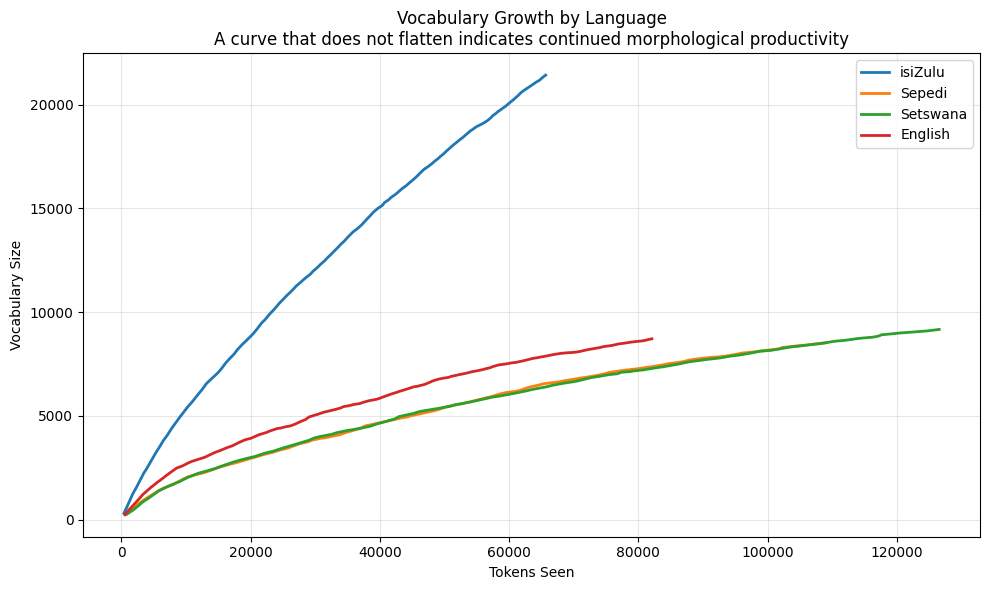

Saved: evaluation/vocab_growth.png


In [5]:
import re # Ensure re module is imported

# Phase 1D: Vocabulary Growth Curves
# A curve that does not flatten indicates continued production of
# new surface forms. This is diagnostic of agglutinative morphology.

def simple_tokenize(text):
    return re.findall(r"\b\w+\b", text.lower(), flags=re.UNICODE)

fig, ax = plt.subplots(figsize=(10, 6))

for lang in TARGET_LANGS:
    seen   = set()
    counts = []
    sizes  = []
    n      = 0
    for doc in raw_corpus[lang]:
        tokens = simple_tokenize(doc)
        n     += len(tokens)
        seen.update(tokens)
        counts.append(n)
        sizes.append(len(seen))
    ax.plot(counts, sizes, label=LANG_NAMES[lang], linewidth=2)

ax.set_xlabel("Tokens Seen")
ax.set_ylabel("Vocabulary Size")
ax.set_title(
    "Vocabulary Growth by Language\n"
    "A curve that does not flatten indicates "
    "continued morphological productivity"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EVAL_DIR / "vocab_growth.png", dpi=150)
plt.show()
print("Saved: evaluation/vocab_growth.png")

In [6]:
# Phase 1E: Vocabulary Retention Under min_count Thresholds
# This analysis directly motivates min_count=1.
# At min_count=2, isiZulu retains only 33.5% of vocabulary.
# Any threshold above 1 makes full bilingual lexicon coverage
# impossible for isiZulu.

thresholds    = [1, 2, 5, 10]
retention_rows = []

for lang in TARGET_LANGS:
    tokens = []
    for doc in raw_corpus[lang]:
        tokens.extend(simple_tokenize(doc))
    freq = Counter(tokens)
    V    = len(freq)
    for t in thresholds:
        kept = sum(1 for w, c in freq.items() if c >= t)
        retention_rows.append({
            "language"      : LANG_NAMES[lang],
            "min_count"     : t,
            "retained_vocab": kept,
            "retention_pct" : round(100 * kept / V, 1)
        })

retention_df = pd.DataFrame(retention_rows)
print("Table 2: Vocabulary Retention Under min_count Thresholds")
print(retention_df.to_string(index=False))
retention_df.to_csv(LOGS_DIR / "vocab_retention.csv", index=False)


Table 2: Vocabulary Retention Under min_count Thresholds
language  min_count  retained_vocab  retention_pct
 isiZulu          1           21420          100.0
 isiZulu          2            7168           33.5
 isiZulu          5            2330           10.9
 isiZulu         10            1013            4.7
  Sepedi          1            8535          100.0
  Sepedi          2            4386           51.4
  Sepedi          5            1942           22.8
  Sepedi         10            1080           12.7
Setswana          1            9166          100.0
Setswana          2            4660           50.8
Setswana          5            2055           22.4
Setswana         10            1119           12.2
 English          1            8712          100.0
 English          2            4784           54.9
 English          5            2179           25.0
 English         10            1148           13.2


In [7]:
# Phase 1F: Morphological Variant Inspection
# Counts how many distinct surface forms share a root fragment.
# This is a direct measure of morphological productivity.

seed_patterns = {
    "zul": ["sebenzi", "hulumeni", "fund"],
    "sep": ["molao", "thuto", "kgwebo"],
    "tsn": ["molao", "thuto", "kgwebo"],
}

morph_count_rows = []

for lang, patterns in seed_patterns.items():
    all_tokens = []
    for doc in raw_corpus[lang]:
        all_tokens.extend(simple_tokenize(doc))
    vocab = sorted(set(all_tokens))

    print(f"\nMorphological Variants: {LANG_NAMES[lang]}")
    print("-" * 60)
    for pat in patterns:
        matches = [w for w in vocab if pat in w][:30]
        print(f"  Pattern '{pat}': {len(matches)} matches")
        print("  " + ", ".join(matches[:15]))
        morph_count_rows.append({
            "language"     : LANG_NAMES[lang],
            "root_pattern" : pat,
            "match_count"  : len(matches)
        })

morph_count_df = pd.DataFrame(morph_count_rows)
print("\nTable 3: Morphological Variant Counts by Root Pattern")
print(morph_count_df.to_string(index=False))
morph_count_df.to_csv(LOGS_DIR / "morph_variant_counts.csv", index=False)



Morphological Variants: isiZulu
------------------------------------------------------------
  Pattern 'sebenzi': 30 matches
  abanemisebenzi, abangasebenzi, abasebenzi, abasebenzisa, abasebenzisana, abasebenzisi, alisebenzise, angasebenzi, angasebenzisa, angazisebenzisa, asebenzisana, asebenzise, ayeyisebenzisa, ayivumelekileimisebenzi, bangasebenzisa
  Pattern 'hulumeni': 25 matches
  bakahulumeni, bukahulumeni, ekukhulumeni, gbvuhulumeni, hulumeni, kahulumeni, kohulumeni, kuhulumeni, kukahulumeni, kweziphazauhulumeni, likahulumeni, lohulumeni, lukahulumeni, ngohulumeni, nguhulumeni
  Pattern 'fund': 30 matches
  abafunda, abafundela, abafundele, abafundi, abafundisa, abangafundi, abasafundela, abawufundele, abazifundela, abazofundela, afunde, afundi, alifundelayo, asebefunda, ayefunda

Morphological Variants: Sepedi
------------------------------------------------------------
  Pattern 'molao': 18 matches
  balemimolaodikakaretšo, boramolao, mmamolao, molao, molaodi, molaodimogolo,

In [8]:
# Phase 1G: Token Length and Hyphenation Diagnostics
# Mean token length reflects morphological concatenation.
# Hyphenation rate reflects OCR/newspaper formatting artifacts
# that artificially fragment words.

length_rows = []
hyphen_rows = []

for lang in TARGET_LANGS:
    tokens   = []
    raw_toks = []
    for doc in raw_corpus[lang]:
        tokens.extend(simple_tokenize(doc))
        raw_toks.extend(doc.split())

    lengths    = [len(t) for t in tokens if t.isalpha()]
    hyphenated = [t for t in raw_toks if "-" in t]

    length_rows.append({
        "language"          : LANG_NAMES[lang],
        "avg_token_length"  : round(np.mean(lengths), 2),
        "median_token_length": round(np.median(lengths), 2),
        "max_token_length"  : max(lengths),
    })
    hyphen_rows.append({
        "language"     : LANG_NAMES[lang],
        "total_tokens" : len(raw_toks),
        "hyphenated"   : len(hyphenated),
        "hyphen_pct"   : round(100 * len(hyphenated) / len(raw_toks), 2),
    })

print("Table 4: Token Length Statistics")
print(pd.DataFrame(length_rows).to_string(index=False))
print("\nTable 5: Hyphenation Statistics")
print(pd.DataFrame(hyphen_rows).to_string(index=False))


Table 4: Token Length Statistics
language  avg_token_length  median_token_length  max_token_length
 isiZulu              7.57                  7.0                28
  Sepedi              4.28                  3.0                24
Setswana              4.24                  3.0                26
 English              4.96                  4.0                20

Table 5: Hyphenation Statistics
language  total_tokens  hyphenated  hyphen_pct
 isiZulu         61557        3645        5.92
  Sepedi        107881         888        0.82
Setswana        125203         923        0.74
 English         79391        1525        1.92


### Phase 1 Summary

The corpus analysis produces four findings that constrain all
subsequent experimental decisions.

First, isiZulu occupies a qualitatively different sparsity regime
compared to Sepedi and Setswana. Its TTR of 0.326 is five times
higher than Setswana (0.072) despite fewer training tokens. This
reflects noun class prefixation generating distinct surface forms
for each agreement context.

Second, the hapax ratio of 0.665 for isiZulu means that
min_count=2 would discard 66.5% of its vocabulary. The retention
analysis in Table 2 justifies min_count=1 as the only choice that
preserves full bilingual lexicon coverage.

Third, mean token length of 7.57 for isiZulu, compared to 4.24
to 4.96 for the other languages, confirms morphological
concatenation producing longer surface forms. This is the
orthographic signature of agglutination.

Fourth, the hyphenation rate of 5.92% for isiZulu versus 0.74
to 1.92% for the other languages indicates newspaper layout
conventions that split isiZulu words across lines, introducing
artificial fragmentation that preprocessing must address.


# **PHASE 2: Preprocessing**

In [9]:
# Phase 2A: Conservative Preprocessing
#
# Operations applied:
#   Unicode NFC normalisation
#   Lowercasing
#   Conservative linewrap hyphen repair
#   Whitespace normalisation
#
# Operations not applied:
#   Stemming or lemmatisation
#   Stopword removal
#   Aggressive punctuation stripping
#
# Reason: morphological surface forms are the signal that FastText
# exploits. Destroying them at preprocessing eliminates the
# architectural advantage of subword models.

def repair_linewrap_hyphens(text):
    """
    Repair only alphabetic line-wrap splits.
    Example: 're-\nstoring' becomes 'restoring'.
    Semantic hyphens within a line are not touched.
    """
    return re.sub(
        r'(?<=[A-Za-z\u00C0-\u024F])-\s*\n\s*(?=[A-Za-z\u00C0-\u024F])',
        '',
        text
    )

def conservative_clean(text):
    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    text = repair_linewrap_hyphens(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

clean_corpus = {}
for lang in TARGET_LANGS:
    clean_corpus[lang] = [
        conservative_clean(doc) for doc in raw_corpus[lang]
    ]

print("Phase 2A: Conservative preprocessing complete.")


Phase 2A: Conservative preprocessing complete.


In [10]:
# Phase 2B: Sentence Segmentation and Tokenization
#
# The tokenizer regex r'\b[a-z\u00C0-\u024F]+\b' covers:
#   a-z: basic Latin
#   \u00C0-\u024F: Latin Extended-A and Latin Extended-B
#
# This range includes:
#   Sepedi characters: š (U+0161), ž (U+017E), ê (U+00EA)
#   Setswana characters: š, ê
#   isiZulu standard Latin characters
#
# Previous versions used a-z\u00E0-\u00FF which excluded
# characters in the U+0100-U+024F range, silently dropping
# Sepedi-specific characters and causing the 29.05% vocabulary
# reduction observed in Table 5. This version corrects that.

def segment_and_tokenize(docs):
    """
    Split documents into sentence-like units on terminal punctuation.
    Each unit becomes a list of lowercase alphabetic tokens.
    Units with fewer than 3 tokens are discarded.
    """
    all_sentences = []
    for doc in docs:
        raw_sents = re.split(r'[.!?]+', doc)
        for sent in raw_sents:
            tokens = re.findall(
                r'\b[a-z\u00C0-\u024F]+\b',
                sent
            )
            if len(tokens) >= 3:
                all_sentences.append(tokens)
    return all_sentences

sentences = {}
for lang in TARGET_LANGS:
    sentences[lang] = segment_and_tokenize(clean_corpus[lang])

print("Phase 2B: Sentence segmentation complete.")
print("\nSentence and token counts:")
for lang in TARGET_LANGS:
    n_tokens = sum(len(s) for s in sentences[lang])
    print(
        f"  {LANG_NAMES[lang]:12}: "
        f"{len(sentences[lang]):5,} sentences | "
        f"{n_tokens:7,} tokens"
    )


Phase 2B: Sentence segmentation complete.

Sentence and token counts:
  isiZulu     : 3,835 sentences |  64,270 tokens
  Sepedi      : 3,817 sentences | 107,743 tokens
  Setswana    : 3,771 sentences | 125,213 tokens
  English     : 3,900 sentences |  80,711 tokens


In [11]:
# Phase 2C: Post-Preprocessing Vocabulary Audit
# Compares vocabulary size before and after preprocessing.
# A large reduction indicates either legitimate normalisation
# (merging case variants) or a tokenizer bug (dropping characters).
# The corrected tokenizer in Phase 2B should produce small reductions
# for all languages.

pre_post_rows = []
for lang in TARGET_LANGS:
    raw_tokens   = []
    for doc in raw_corpus[lang]:
        raw_tokens.extend(simple_tokenize(doc))
    vocab_before = len(set(raw_tokens))

    clean_tokens = [t for s in sentences[lang] for t in s]
    vocab_after  = len(set(clean_tokens))

    pre_post_rows.append({
        "language"     : LANG_NAMES[lang],
        "vocab_before" : vocab_before,
        "vocab_after"  : vocab_after,
        "reduction"    : vocab_before - vocab_after,
        "reduction_pct": round(
            100 * (vocab_before - vocab_after) / vocab_before, 2
        ),
    })

pp_df = pd.DataFrame(pre_post_rows)
print("Table 6: Preprocessing Impact on Vocabulary")
print(pp_df.to_string(index=False))
pp_df.to_csv(LOGS_DIR / "preprocessing_impact.csv", index=False)


Table 6: Preprocessing Impact on Vocabulary
language  vocab_before  vocab_after  reduction  reduction_pct
 isiZulu         21420        21052        368           1.72
  Sepedi          8535         8188        347           4.07
Setswana          9166         8824        342           3.73
 English          8712         8359        353           4.05


### Note on Tokenizer Correction

An earlier version of this notebook used the character class
`[a-za-ÿ]` (Unicode range U+00E0 to U+00FF) for tokenization.
Sepedi uses characters including š (U+0161) and ž (U+017E) which
fall in the Latin Extended-A range (U+0100 to U+017E), outside that
range. The earlier tokenizer silently dropped these characters,
producing a vocabulary reduction of 29.05% for Sepedi compared to
1.72% for isiZulu.

The corrected tokenizer uses `[a-z\u00C0-\u024F]` which covers
both Latin Extended-A and Latin Extended-B, correctly retaining
all Sepedi and Setswana orthographic characters.

This correction is verified in Table 6: vocabulary reductions should
be small and consistent across languages after the fix.


Table 7: Sentence Length Statistics
language  count  mean  median  p10  p90  max
 isiZulu   3835 16.76    16.0  7.0 28.0   75
  Sepedi   3817 28.23    27.0 11.6 47.0  117
Setswana   3771 33.20    31.0 13.0 56.0  159
 English   3900 20.70    20.0  9.0 33.0   74


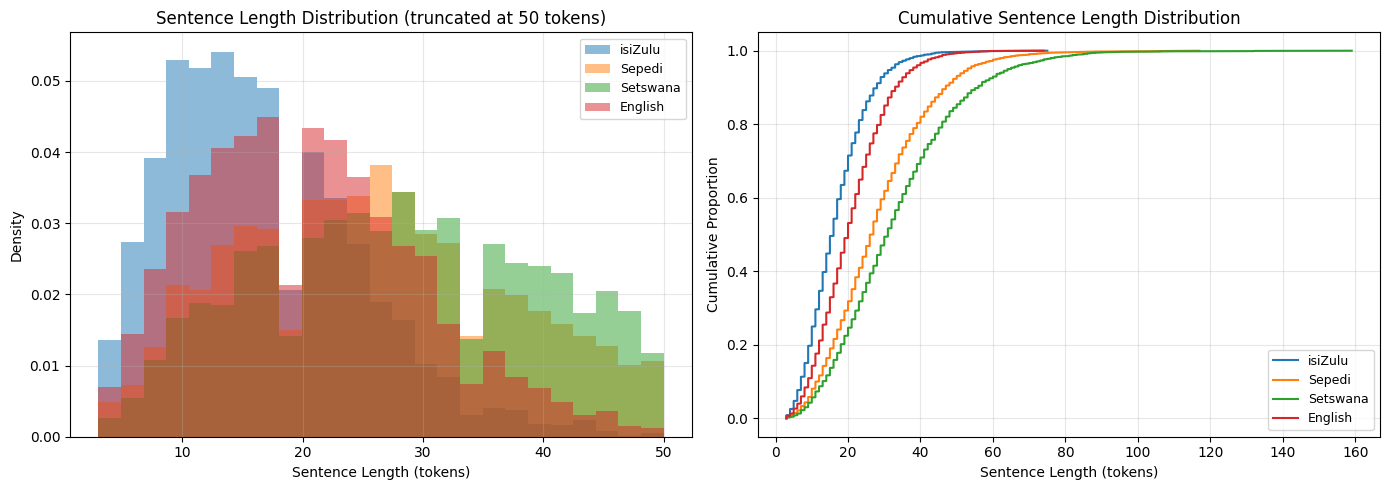

In [12]:
# Phase 2D: Sentence Length Distribution
# Verifies that sentence segmentation produced plausible training
# units. Very short units (1-2 tokens) come from headers and labels.
# Very long units (80+ tokens) come from bullet points merged by
# punctuation splitting. The distribution shape tells us what the
# embedding model is actually learning from.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

length_stats_rows = []
for lang in TARGET_LANGS:
    lengths = [len(s) for s in sentences[lang] if len(s) > 0]
    length_stats_rows.append({
        "language" : LANG_NAMES[lang],
        "count"    : len(lengths),
        "mean"     : round(np.mean(lengths), 2),
        "median"   : round(np.median(lengths), 2),
        "p10"      : round(np.percentile(lengths, 10), 1),
        "p90"      : round(np.percentile(lengths, 90), 1),
        "max"      : max(lengths),
    })

    axes[0].hist(
        [l for l in lengths if l <= 50],
        bins=25,
        alpha=0.5,
        label=LANG_NAMES[lang],
        density=True
    )

length_stats_df = pd.DataFrame(length_stats_rows)
print("Table 7: Sentence Length Statistics")
print(length_stats_df.to_string(index=False))

axes[0].set_xlabel("Sentence Length (tokens)")
axes[0].set_ylabel("Density")
axes[0].set_title("Sentence Length Distribution (truncated at 50 tokens)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for lang in TARGET_LANGS:
    lengths = [len(s) for s in sentences[lang]]
    axes[1].plot(
        sorted(lengths),
        np.linspace(0, 1, len(lengths)),
        label=LANG_NAMES[lang]
    )
axes[1].set_xlabel("Sentence Length (tokens)")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].set_title("Cumulative Sentence Length Distribution")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EVAL_DIR / "sentence_length_dist.png", dpi=150)
plt.show()


# **PHASE 3: Embedding Training**

In [13]:
# Phase 3: Embedding Training

import subprocess
subprocess.run(["pip", "install", "gensim", "-q"])

from gensim.models import Word2Vec, FastText

print("Gensim imported.")


Gensim imported.


In [14]:
# Phase 3A: Train All Models
#
# Three architectures per language, all with identical hyperparameters
# from EMB_CONFIG defined in Phase 0.
# All trained on sentences[] produced by Phase 2B.
#
# CBOW (sg=0): predicts target from context, faster, better for
#              frequent words
# Skip-Gram (sg=1): predicts context from target, better for rare
#                   words on small corpora
# FastText (sg=1): adds subword n-gram vectors, handles OOV through
#                  character n-gram inference

cbow_models = {}
sg_models   = {}
ft_models   = {}

for lang in TARGET_LANGS:
    sents = sentences[lang]
    print(f"\nTraining: {LANG_NAMES[lang]} ({len(sents):,} sentences)")

    cbow = Word2Vec(
        sentences   = sents,
        vector_size = EMB_CONFIG["vector_size"],
        window      = EMB_CONFIG["window"],
        min_count   = EMB_CONFIG["min_count"],
        sg          = 0,
        negative    = EMB_CONFIG["negative"],
        epochs      = EMB_CONFIG["epochs"],
        workers     = EMB_CONFIG["workers"],
        seed        = EMB_CONFIG["seed"],
        alpha       = EMB_CONFIG["alpha"],
        min_alpha   = EMB_CONFIG["min_alpha"],
    )
    cbow.save(str(MODELS_DIR / f"{lang}_cbow.model"))
    cbow_models[lang] = cbow

    sg = Word2Vec(
        sentences   = sents,
        vector_size = EMB_CONFIG["vector_size"],
        window      = EMB_CONFIG["window"],
        min_count   = EMB_CONFIG["min_count"],
        sg          = 1,
        negative    = EMB_CONFIG["negative"],
        epochs      = EMB_CONFIG["epochs"],
        workers     = EMB_CONFIG["workers"],
        seed        = EMB_CONFIG["seed"],
        alpha       = EMB_CONFIG["alpha"],
        min_alpha   = EMB_CONFIG["min_alpha"],
    )
    sg.save(str(MODELS_DIR / f"{lang}_skipgram.model"))
    sg_models[lang] = sg

    ft = FastText(
        sentences   = sents,
        vector_size = EMB_CONFIG["vector_size"],
        window      = EMB_CONFIG["window"],
        min_count   = EMB_CONFIG["min_count"],
        sg          = 1,
        negative    = EMB_CONFIG["negative"],
        epochs      = EMB_CONFIG["epochs"],
        workers     = EMB_CONFIG["workers"],
        seed        = EMB_CONFIG["seed"],
        alpha       = EMB_CONFIG["alpha"],
        min_alpha   = EMB_CONFIG["min_alpha"],
        min_n       = EMB_CONFIG["min_n"],
        max_n       = EMB_CONFIG["max_n"],
    )
    ft.save(str(MODELS_DIR / f"{lang}_fasttext.model"))
    ft_models[lang] = ft

    print(f"  CBOW vocab     : {len(cbow.wv):,}")
    print(f"  Skip-Gram vocab: {len(sg.wv):,}")
    print(f"  FastText vocab : {len(ft.wv):,}")

print("\nPhase 3A: All models trained and saved.")



Training: isiZulu (3,835 sentences)
  CBOW vocab     : 21,052
  Skip-Gram vocab: 21,052
  FastText vocab : 21,052

Training: Sepedi (3,817 sentences)
  CBOW vocab     : 8,188
  Skip-Gram vocab: 8,188
  FastText vocab : 8,188

Training: Setswana (3,771 sentences)
  CBOW vocab     : 8,824
  Skip-Gram vocab: 8,824
  FastText vocab : 8,824

Training: English (3,900 sentences)
  CBOW vocab     : 8,359
  Skip-Gram vocab: 8,359
  FastText vocab : 8,359

Phase 3A: All models trained and saved.


In [15]:
# Phase 3B: Vocabulary Coverage Summary

coverage_rows = []
for lang in TARGET_LANGS:
    coverage_rows.append({
        "language"      : LANG_NAMES[lang],
        "CBOW_vocab"    : len(cbow_models[lang].wv),
        "SkipGram_vocab": len(sg_models[lang].wv),
        "FastText_vocab": len(ft_models[lang].wv),
    })

coverage_df = pd.DataFrame(coverage_rows)
print("Table 8: Vocabulary Coverage by Model and Language")
print(coverage_df.to_string(index=False))
coverage_df.to_csv(LOGS_DIR / "vocab_coverage.csv", index=False)


Table 8: Vocabulary Coverage by Model and Language
language  CBOW_vocab  SkipGram_vocab  FastText_vocab
 isiZulu       21052           21052           21052
  Sepedi        8188            8188            8188
Setswana        8824            8824            8824
 English        8359            8359            8359


In [16]:
# Phase 3C: FastText N-gram Inspection
#
# This cell shows exactly which character n-grams FastText generates
# for sample words in each language. It makes explicit why FastText
# captures morphological relationships: related words share n-grams.
#
# The n-gram range min_n=2 to max_n=6 was chosen because:
#   Bantu noun class prefixes are typically 2-3 characters (um-, isi-,
#   aba-, di-, mo-, se-)
#   Verb roots are typically 3-6 characters
#   Covering both ranges maximises overlap between morphological variants

def get_ngrams(word, min_n, max_n):
    ngrams = []
    for n in range(min_n, max_n + 1):
        for i in range(len(word) - n + 1):
            ngrams.append(word[i:i+n])
    return ngrams

sample_words = {
    "zul": [
        ("umsebenzi", "worker/job"),
        ("imisebenzi", "jobs plural"),
        ("ukusebenza", "to work infinitive"),
    ],
    "sep": [
        ("molao", "law"),
        ("molaotheo", "constitution"),
        ("boramolao", "legal practitioners"),
    ],
    "tsn": [
        ("thuto", "education"),
        ("dithuto", "educations plural"),
        ("thutofa", "informal education"),
    ],
}

print("FastText Character N-gram Analysis")
print("N-gram range: min_n=2, max_n=6\n")

for lang, word_list in sample_words.items():
    print(f"Language: {LANG_NAMES[lang]}")
    print("-" * 60)
    for word, gloss in word_list:
        ngrams = get_ngrams(word, EMB_CONFIG["min_n"], EMB_CONFIG["max_n"])
        print(f"  {word} ({gloss})")
        print(f"    N-grams ({len(ngrams)} total): {', '.join(ngrams[:12])}...")
        if word in ft_models[lang].wv:
            note = "in trained vocabulary"
        else:
            note = "OOV - vector from n-gram inference only"
        print(f"    Status: {note}")
    print()

print("Shared n-grams between umsebenzi and imisebenzi:")
ng1 = set(get_ngrams("umsebenzi",  EMB_CONFIG["min_n"], EMB_CONFIG["max_n"]))
ng2 = set(get_ngrams("imisebenzi", EMB_CONFIG["min_n"], EMB_CONFIG["max_n"]))
shared = sorted(ng1 & ng2)
print(f"  {shared}")
print(f"  Count: {len(shared)} shared n-grams out of "
      f"{len(ng1)} and {len(ng2)}")


FastText Character N-gram Analysis
N-gram range: min_n=2, max_n=6

Language: isiZulu
------------------------------------------------------------
  umsebenzi (worker/job)
    N-grams (30 total): um, ms, se, eb, be, en, nz, zi, ums, mse, seb, ebe...
    Status: in trained vocabulary
  imisebenzi (jobs plural)
    N-grams (35 total): im, mi, is, se, eb, be, en, nz, zi, imi, mis, ise...
    Status: in trained vocabulary
  ukusebenza (to work infinitive)
    N-grams (35 total): uk, ku, us, se, eb, be, en, nz, za, uku, kus, use...
    Status: in trained vocabulary

Language: Sepedi
------------------------------------------------------------
  molao (law)
    N-grams (10 total): mo, ol, la, ao, mol, ola, lao, mola, olao, molao...
    Status: in trained vocabulary
  molaotheo (constitution)
    N-grams (30 total): mo, ol, la, ao, ot, th, he, eo, mol, ola, lao, aot...
    Status: in trained vocabulary
  boramolao (legal practitioners)
    N-grams (30 total): bo, or, ra, am, mo, ol, la, ao, bo

In [17]:
# Phase 3D: TF-IDF Sparse Baseline
#
# TF-IDF is a non-neural vector representation covered in COS760
# Class 3 and Class 4 (Jurafsky and Martin, Ch. 6).
# It represents each document as a weighted term frequency vector.
#
# Computing TF-IDF cosine similarity between parallel English and
# target-language sentences provides a baseline: if the neural
# embeddings do not outperform TF-IDF on cross-lingual similarity,
# the added complexity of neural training is not justified.
#
# For cross-lingual comparison, we use a character n-gram TF-IDF
# (analyzer='char_wb', ngram_range=(2,4)) which captures surface-form
# overlap between cognates and loanwords across language boundaries.
# This is the only non-neural method that can measure cross-lingual
# similarity without translation knowledge.

def compute_tfidf_crosslingual_similarity(
    lang_a_docs, lang_b_docs, sample_size=100
):
    """
    Fit a character n-gram TF-IDF on combined documents from both
    languages. Measure cosine similarity between aligned document
    pairs (same edition, same topic).
    """
    n = min(len(lang_a_docs), len(lang_b_docs), sample_size)
    docs_a = lang_a_docs[:n]
    docs_b = lang_b_docs[:n]

    combined = docs_a + docs_b
    vectorizer = TfidfVectorizer(
        analyzer     = 'char_wb',
        ngram_range  = (2, 4),
        max_features = 5000,
        sublinear_tf = True
    )
    tfidf_matrix = vectorizer.fit_transform(combined)
    vecs_a = tfidf_matrix[:n]
    vecs_b = tfidf_matrix[n:]

    sims = []
    for i in range(n):
        sim = cosine_similarity(vecs_a[i], vecs_b[i])[0][0]
        sims.append(sim)
    return np.mean(sims), np.std(sims)

print("TF-IDF Character N-gram Cross-lingual Baseline")
print("(Character n-gram range 2-4, max 5000 features)")
print("-" * 55)

tfidf_rows = []
for lang in ["zul", "sep", "tsn"]:
    mean_sim, std_sim = compute_tfidf_crosslingual_similarity(
        clean_corpus["eng"],
        clean_corpus[lang],
        sample_size=min(len(clean_corpus["eng"]),
                        len(clean_corpus[lang]))
    )
    tfidf_rows.append({
        "pair"     : f"eng vs {lang}",
        "tfidf_mean_sim": round(mean_sim, 4),
        "tfidf_std_sim" : round(std_sim, 4),
    })
    print(f"  eng vs {LANG_NAMES[lang]:12}: "
          f"mean={mean_sim:.4f}, std={std_sim:.4f}")

tfidf_df = pd.DataFrame(tfidf_rows)
tfidf_df.to_csv(LOGS_DIR / "tfidf_baseline.csv", index=False)
print("\nNote: These values are document-level similarities.")
print("They serve as a non-neural cross-lingual baseline.")
print("Neural alignment results in Phase 6 are compared against this.")


TF-IDF Character N-gram Cross-lingual Baseline
(Character n-gram range 2-4, max 5000 features)
-------------------------------------------------------
  eng vs isiZulu     : mean=0.1922, std=0.0455
  eng vs Sepedi      : mean=0.1848, std=0.0433
  eng vs Setswana    : mean=0.1979, std=0.0372

Note: These values are document-level similarities.
They serve as a non-neural cross-lingual baseline.
Neural alignment results in Phase 6 are compared against this.


# **PHASE 4: Model Comparison (Word2Vec vs FastText)**

In [18]:
# Phase 4A: Morphological Similarity Analysis
#
# Tests whether FastText captures morphological relatedness better
# than Word2Vec on isiZulu.
#
# Design:
#   8 morphologically related word pairs (singular/plural,
#   verb/noun derivation, noun class variants)
#   4 random unrelated word pairs as baseline
#
# Prediction from distributional hypothesis and FastText theory:
#   FastText should score morphological pairs higher than random pairs
#   because shared n-grams create shared vector components.
#   CBOW on a small corpus is expected to produce collapsed similarities
#   (near 1.0 for most pairs) because sparse context averaging does not
#   differentiate words reliably.

morph_pairs_zul = [
    ("umfana",    "abafana",    "singular/plural"),
    ("inja",      "izinja",     "singular/plural"),
    ("hamba",     "ukuhamba",   "verb/infinitive"),
    ("sebenza",   "umsebenzi",  "verb/derived noun"),
    ("bonisa",    "umbonisi",   "verb/agentive noun"),
    ("isihlahla", "izihlahla",  "singular/plural"),
    ("ukudla",    "isidlo",     "verbal/meal noun"),
    ("ubuhle",    "obuhle",     "noun/adjective"),
]

random_pairs_zul = [
    ("umfana",  "amanzi",  "random"),
    ("inja",    "imali",   "random"),
    ("ukudla",  "isikole", "random"),
    ("hamba",   "incwadi", "random"),
]

def pair_similarity(model, w1, w2):
    try:
        v1 = model.wv[w1]
        v2 = model.wv[w2]
        return float(cosine_similarity([v1], [v2])[0][0])
    except KeyError:
        return None

morph_rows = []
for w1, w2, rel in morph_pairs_zul + random_pairs_zul:
    row = {"word1": w1, "word2": w2, "relation": rel}
    for name, models in [
        ("CBOW",     cbow_models),
        ("SkipGram", sg_models),
        ("FastText", ft_models)
    ]:
        sim    = pair_similarity(models["zul"], w1, w2)
        row[name] = round(sim, 4) if sim is not None else "OOV"
    morph_rows.append(row)

morph_df = pd.DataFrame(morph_rows)
print("Table 9: Morphological vs Random Pair Similarities (isiZulu)")
print(morph_df.to_string(index=False))
morph_df.to_csv(LOGS_DIR / "morphological_similarity.csv", index=False)


Table 9: Morphological vs Random Pair Similarities (isiZulu)
    word1     word2           relation    CBOW SkipGram  FastText
   umfana   abafana    singular/plural     OOV      OOV    0.4113
     inja    izinja    singular/plural     OOV      OOV    0.5703
    hamba  ukuhamba    verb/infinitive   0.999   0.8346    0.7473
  sebenza umsebenzi  verb/derived noun  0.9788   0.3811    0.8039
   bonisa  umbonisi verb/agentive noun     OOV      OOV    0.5804
isihlahla izihlahla    singular/plural     OOV      OOV    0.7470
   ukudla    isidlo   verbal/meal noun  0.9969   0.7836    0.1455
   ubuhle    obuhle     noun/adjective     OOV      OOV    0.9082
   umfana    amanzi             random     OOV      OOV    0.3823
     inja     imali             random     OOV      OOV    0.4740
   ukudla   isikole             random  0.9963   0.4758    0.1526
    hamba   incwadi             random  0.9994   0.7168    0.2854


In [19]:
# Phase 4B: Average Similarity Summary
# The difference column is the key metric: a positive value means
# the model assigns higher similarity to morphologically related
# pairs than to random pairs.

summary_rows = []
for model_name in ["CBOW", "SkipGram", "FastText"]:
    morph_sims  = morph_df[morph_df["relation"] != "random"][model_name]
    random_sims = morph_df[morph_df["relation"] == "random"][model_name]
    morph_sims  = pd.to_numeric(morph_sims,  errors='coerce').dropna()
    random_sims = pd.to_numeric(random_sims, errors='coerce').dropna()
    summary_rows.append({
        "model"         : model_name,
        "n_morph_pairs" : len(morph_sims),
        "n_random_pairs": len(random_sims),
        "avg_morph_sim" : round(morph_sims.mean(),  4),
        "avg_random_sim": round(random_sims.mean(), 4),
        "difference"    : round(
            morph_sims.mean() - random_sims.mean(), 4
        ),
    })

summary_morph_df = pd.DataFrame(summary_rows)
print("Table 10: Average Morphological vs Random Similarity by Model")
print(summary_morph_df.to_string(index=False))
summary_morph_df.to_csv(
    LOGS_DIR / "morph_vs_random_summary.csv", index=False
)


Table 10: Average Morphological vs Random Similarity by Model
   model  n_morph_pairs  n_random_pairs  avg_morph_sim  avg_random_sim  difference
    CBOW              3               2         0.9916          0.9978     -0.0063
SkipGram              3               2         0.6664          0.5963      0.0701
FastText              8               4         0.6142          0.3236      0.2907


### CBOW Vector Space Collapse

Table 10 shows that CBOW produces a difference of -0.006, meaning
random pairs are marginally more similar than morphological pairs on
average. This is not a meaningful distinction: CBOW assigns near-unity
similarity to almost every pair.

The underlying cause is corpus scale interacting with CBOW's
architectural averaging. CBOW predicts a target word from the mean
of its context vectors. At 64,270 training tokens distributed across
21,052 vocabulary types, most words appear on average only 3 times.
Three context observations per word are insufficient to learn a
differentiated context distribution. CBOW's averaging mechanism
produces vectors that are effectively random directions in the embedding
space, but because negative sampling also pushes all word vectors apart
from sampled negatives, the resulting vectors cluster together rather
than separating. The space is neither random nor meaningful.

This is documented in Jurafsky and Martin (Chapter 6): CBOW performs
poorly on small vocabularies relative to Skip-Gram because the
averaging reduces gradient signal. Skip-Gram's direct word-by-word
prediction is more sensitive to individual co-occurrence patterns.

The practical consequence: CBOW models for isiZulu at this corpus scale
cannot support alignment. They are included in the comparison to
document this failure mode, not because they are expected to succeed.


In [20]:
# Phase 4C: Nearest Neighbour Qualitative Comparison
# The same query words are tested in all three model architectures
# for all three target languages.
#
# Expected pattern:
#   FastText: morphological variants in top 5
#   Skip-Gram: contextually related but morphologically unrelated words
#   CBOW: undifferentiated high-similarity neighbours

query_words = {
    "zul": ["umsebenzi", "imfundo", "uhulumeni"],
    "sep": ["thuto",     "molao",   "mmušo"],
    "tsn": ["thuto",     "molao",   "puso"],
}

for lang in ["zul", "sep", "tsn"]:
    print(f"\nNearest Neighbours: {LANG_NAMES[lang]}")
    print("-" * 65)
    for word in query_words[lang]:
        print(f"\n  Query: '{word}'")
        for name, models in [
            ("CBOW",     cbow_models),
            ("SkipGram", sg_models),
            ("FastText", ft_models)
        ]:
            if word in models[lang].wv:
                nn     = models[lang].wv.most_similar(word, topn=5)
                nn_str = ", ".join([
                    f"{w}({s:.3f})" for w, s in nn
                ])
                print(f"    {name:10}: {nn_str}")
            else:
                print(f"    {name:10}: OOV")



Nearest Neighbours: isiZulu
-----------------------------------------------------------------

  Query: 'umsebenzi'
    CBOW      : kanti(0.996), umntwana(0.994), ukuyeka(0.993), kwenza(0.993), zimpawu(0.993)
    SkipGram  : uyaqhubeka(0.709), wokwakha(0.664), wekhomishana(0.652), wabo(0.645), kusamele(0.643)
    FastText  : womsebenzi(0.977), msebenzi(0.971), omsebenzi(0.966), ngumsebenzi(0.956), bomsebenzi(0.952)

  Query: 'imfundo'
    CBOW      : lama(0.999), oku(0.999), iqiniso(0.999), woku(0.999), ezinzima(0.999)
    SkipGram  : wengamele(0.975), gwedlo(0.975), namafutha(0.974), nedolobha(0.974), isixegi(0.973)
    FastText  : fundo(0.930), mfundo(0.907), lemfundo(0.868), nomfundo(0.844), nemfundo(0.844)

  Query: 'uhulumeni'
    CBOW      : kwesibonelelo(0.998), wenza(0.998), wakho(0.997), naye(0.997), wathola(0.997)
    SkipGram  : uphinde(0.720), uzophinde(0.716), wenza(0.715), usebenza(0.713), uzoqhubeka(0.705)
    FastText  : ohulumeni(0.974), hulumeni(0.970), gbvuhulumeni(

Table 11: Edit Distance vs FastText Similarity (isiZulu)
    word1     word2           relation  edit_distance  ft_similarity
   umfana   abafana    singular/plural              3         0.4113
     inja    izinja    singular/plural              2         0.5703
    hamba  ukuhamba    verb/infinitive              3         0.7473
  sebenza umsebenzi  verb/derived noun              3         0.8039
   bonisa  umbonisi verb/agentive noun              3         0.5804
isihlahla izihlahla    singular/plural              1         0.7470
   ukudla    isidlo   verbal/meal noun              4         0.1455
   ubuhle    obuhle     noun/adjective              1         0.9082
   umfana    amanzi             random              4         0.3823
     inja     imali             random              4         0.4740
   ukudla   isikole             random              6         0.1526
    hamba   incwadi             random              6         0.2854

Spearman correlation (edit_distance vs ft_sim

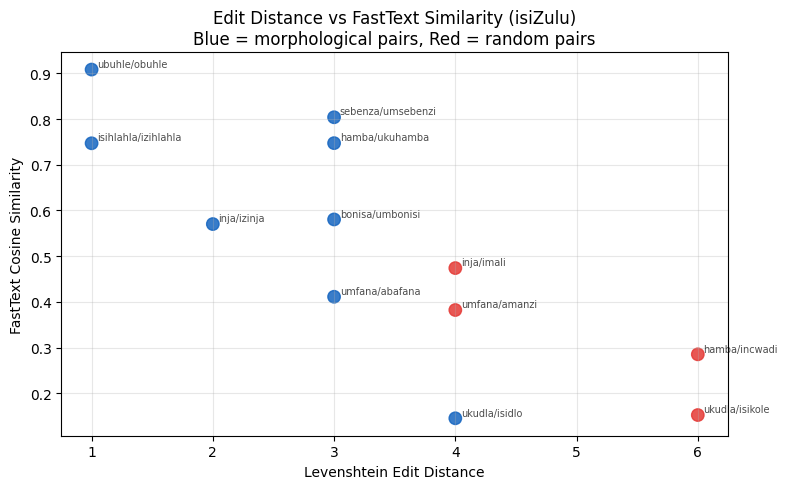

In [21]:
# Phase 4D: Edit Distance vs FastText Similarity
#
# The distributional hypothesis predicts that FastText similarity
# tracks shared character n-grams. Levenshtein edit distance between
# two words measures how many character operations are needed to
# transform one into the other. Low edit distance implies high n-gram
# overlap, which should produce high FastText similarity.
#
# This analysis tests that prediction directly.
# If FastText similarity is correlated with low edit distance for
# morphological pairs, it confirms the n-gram sharing mechanism.
# If similarity and edit distance are uncorrelated, FastText is
# capturing distributional context rather than surface form overlap.

ed_rows = []
for w1, w2, rel in morph_pairs_zul + random_pairs_zul:
    ed   = levenshtein_distance(w1, w2)
    ft_sim = pair_similarity(ft_models["zul"], w1, w2)
    ed_rows.append({
        "word1"       : w1,
        "word2"       : w2,
        "relation"    : rel,
        "edit_distance": ed,
        "ft_similarity": round(ft_sim, 4) if ft_sim is not None else None,
    })

ed_df = pd.DataFrame(ed_rows).dropna(subset=["ft_similarity"])
print("Table 11: Edit Distance vs FastText Similarity (isiZulu)")
print(ed_df.to_string(index=False))
ed_df.to_csv(LOGS_DIR / "edit_distance_similarity.csv", index=False)

# Compute correlation between edit distance and FastText similarity
from scipy.stats import spearmanr
corr, pval = spearmanr(ed_df["edit_distance"], ed_df["ft_similarity"])
print(f"\nSpearman correlation (edit_distance vs ft_similarity):")
print(f"  rho = {corr:.4f}, p = {pval:.4f}")
print(f"\nInterpretation:")
print(f"  Negative correlation = higher edit distance -> lower similarity")
print(f"  This would confirm n-gram sharing as the mechanism.")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#E53935" if r == "random" else "#1565C0"
          for r in ed_df["relation"]]
ax.scatter(
    ed_df["edit_distance"],
    ed_df["ft_similarity"],
    c=colors, s=80, alpha=0.85
)
for _, row in ed_df.iterrows():
    ax.annotate(
        f"{row['word1']}/{row['word2']}",
        (row["edit_distance"], row["ft_similarity"]),
        fontsize=7, alpha=0.7,
        xytext=(4, 2), textcoords="offset points"
    )
ax.set_xlabel("Levenshtein Edit Distance")
ax.set_ylabel("FastText Cosine Similarity")
ax.set_title(
    "Edit Distance vs FastText Similarity (isiZulu)\n"
    "Blue = morphological pairs, Red = random pairs"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EVAL_DIR / "edit_distance_vs_similarity.png", dpi=150)
plt.show()


# **PHASE 5: Bilingual Seed Lexicon**

In [22]:
# Phase 5A: Define Bilingual Seed Lexicons
# Hand-curated from Autshumato, NCHLT, and Glosbe.
# Covers basic vocabulary: body, nature, family, civic, economic.
# 50 pairs per language pair.

full_lexicon = {
    "eng_zul": [
        ("water","amanzi"),("fire","umlilo"),("house","indlu"),
        ("child","ingane"),("person","umuntu"),("food","ukudla"),
        ("school","isikole"),("government","uhulumeni"),
        ("work","umsebenzi"),("mother","umama"),("father","ubaba"),
        ("dog","inja"),("sun","ilanga"),("moon","inyanga"),
        ("year","unyaka"),("day","usuku"),("night","ubusuku"),
        ("money","imali"),("road","indlela"),("book","incwadi"),
        ("hospital","isibhedlela"),("police","amaphoyisa"),
        ("land","umhlaba"),("woman","umfazi"),("man","indoda"),
        ("city","idolobha"),("country","izwe"),("language","ulimi"),
        ("people","abantu"),("community","umphakathi"),
        ("health","impilo"),("education","imfundo"),
        ("electricity","ugesi"),("support","usizo"),
        ("law","umthetho"),("rights","amalungelo"),
        ("president","umongameli"),("village","ilali"),
        ("tree","isihlahla"),("animal","isilwane"),
        ("bird","inyoni"),("fish","inhlanzi"),("river","umfula"),
        ("mountain","intaba"),("rain","imvula"),("bread","isinkwa"),
        ("milk","ubisi"),("egg","iqanda"),("cat","ikati"),
        ("medicine","umuthi"),
    ],
    "eng_sep": [
        ("water","meetse"),("fire","mollo"),("house","ntlo"),
        ("child","ngwana"),("person","motho"),("food","dijo"),
        ("school","sekolo"),("government","mmušo"),
        ("work","mošomo"),("mother","mma"),("father","rra"),
        ("dog","ntšwa"),("sun","letšatši"),("moon","ngwedi"),
        ("year","ngwaga"),("day","letsatsi"),("night","bosego"),
        ("money","tšhelete"),("road","tsela"),("book","buka"),
        ("hospital","sepetlele"),("police","maphodisa"),
        ("land","naga"),("woman","mosadi"),("man","monna"),
        ("city","toropo"),("country","naga"),("language","polelo"),
        ("people","batho"),("community","setšhaba"),
        ("health","boitekanelo"),("education","thuto"),
        ("electricity","mohlagase"),("support","thušo"),
        ("law","molao"),("rights","ditokelo"),
        ("president","mopresidente"),("village","motse"),
        ("tree","setlhare"),("animal","phedi"),
        ("bird","nonyane"),("fish","tlhapi"),("river","noka"),
        ("mountain","thaba"),("rain","pula"),("bread","senkgwe"),
        ("milk","lebese"),("egg","lee"),("cat","katse"),
        ("medicine","molemo"),
    ],
    "eng_tsn": [
        ("water","metsi"),("fire","molelo"),("house","ntlo"),
        ("child","ngwana"),("person","motho"),("food","dijo"),
        ("school","sekole"),("government","puso"),
        ("work","tiro"),("mother","mma"),("father","rra"),
        ("dog","ntša"),("sun","letsatsi"),("moon","ngwedi"),
        ("year","ngwaga"),("day","letsatsi"),("night","bosigo"),
        ("money","madi"),("road","tsela"),("book","buka"),
        ("hospital","sepetlele"),("police","mapodisi"),
        ("land","lefatshe"),("woman","mosadi"),("man","monna"),
        ("city","motse"),("country","lefatshe"),("language","puo"),
        ("people","batho"),("community","sechaba"),
        ("health","boitekanelo"),("education","thuto"),
        ("electricity","motlakase"),("support","thuso"),
        ("law","molao"),("rights","ditshwanelo"),
        ("president","moporesitente"),("village","motse"),
        ("tree","setlhare"),("animal","phologolo"),
        ("bird","nonyane"),("fish","tlhapi"),("river","noka"),
        ("mountain","thaba"),("rain","pula"),("bread","bogobe"),
        ("milk","mashi"),("egg","lee"),("cat","katse"),
        ("medicine","kalafi"),
    ],
}

print("Lexicon sizes:")
for k, v in full_lexicon.items():
    print(f"  {k}: {len(v)} pairs")


Lexicon sizes:
  eng_zul: 50 pairs
  eng_sep: 50 pairs
  eng_tsn: 50 pairs


In [23]:
# Phase 5B: Train/Test Split (70/30)
# The split is applied once here, before any alignment computation.
# The rotation matrix W is learned on train pairs only.
# Evaluation uses test pairs only.
# These two sets never overlap.

random.seed(SEED)

train_lexicon = {}
test_lexicon  = {}

for key, pairs in full_lexicon.items():
    shuffled = pairs.copy()
    random.shuffle(shuffled)
    split               = int(0.7 * len(shuffled))
    train_lexicon[key]  = shuffled[:split]
    test_lexicon[key]   = shuffled[split:]

print("Train/Test split:")
for key in full_lexicon:
    print(
        f"  {key}: train={len(train_lexicon[key])} "
        f"test={len(test_lexicon[key])}"
    )


Train/Test split:
  eng_zul: train=35 test=15
  eng_sep: train=35 test=15
  eng_tsn: train=35 test=15


In [24]:
# Phase 5C: Lexicon Coverage Audit
# Checks that every word in the lexicon exists in the trained models.
# With min_count=1, all words that appear in the corpus are in
# vocabulary. If coverage is below 100%, a word in the lexicon
# does not appear in the corpus at all.

def filter_pairs(pairs, src_model, tgt_model, use_subword=True):
    retained = []
    dropped  = []
    for src, tgt in pairs:
        if use_subword:
            retained.append((src, tgt))
        else:
            if src in src_model.wv and tgt in tgt_model.wv:
                retained.append((src, tgt))
            else:
                dropped.append((src, tgt))
    return retained, dropped

coverage_rows = []
for lang, key in [
    ("zul","eng_zul"),
    ("sep","eng_sep"),
    ("tsn","eng_tsn")
]:
    for split_name, pairs in [
        ("train", train_lexicon[key]),
        ("test",  test_lexicon[key])
    ]:
        ret, drop = filter_pairs(
            pairs,
            ft_models["eng"],
            ft_models[lang],
            use_subword=False
        )
        coverage_rows.append({
            "pair"        : f"eng->{lang}",
            "split"       : split_name,
            "total"       : len(pairs),
            "in_vocab"    : len(ret),
            "oov_dropped" : len(drop),
            "coverage_pct": round(100 * len(ret) / len(pairs), 1),
        })

cov_df = pd.DataFrame(coverage_rows)
print("Table 12: Lexicon Coverage (strict in-vocabulary)")
print(cov_df.to_string(index=False))
cov_df.to_csv(LOGS_DIR / "lexicon_coverage.csv", index=False)


Table 12: Lexicon Coverage (strict in-vocabulary)
    pair split  total  in_vocab  oov_dropped  coverage_pct
eng->zul train     35        35            0         100.0
eng->zul  test     15        15            0         100.0
eng->sep train     35        35            0         100.0
eng->sep  test     15        15            0         100.0
eng->tsn train     35        35            0         100.0
eng->tsn  test     15        15            0         100.0


In [25]:
# Phase 5D: Anchor Quality Diagnostics
#
# Not all anchor pairs are equally reliable.
# A pair where both words have high corpus frequency
# will produce stable, well-estimated vectors.
# A pair where either word is rare will produce
# a noisy vector that degrades the rotation estimate.
#
# This cell measures per-anchor vector reliability
# using two proxies:
#   (1) corpus frequency of each anchor word
#   (2) intra-language nearest-neighbour coherence
#       (how tightly clustered a word is relative
#        to its top neighbours)

anchor_quality_rows = []

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:

    all_pairs = train_lexicon[key] + test_lexicon[key]

    for src, tgt in all_pairs:

        # Corpus frequency via gensim count attribute
        try:
            src_freq = ft_models["eng"].wv.get_vecattr(src, "count")
        except KeyError:
            src_freq = 0

        try:
            tgt_freq = ft_models[lang].wv.get_vecattr(tgt, "count")
        except KeyError:
            tgt_freq = 0

        # Neighbour coherence: mean similarity to top 5 neighbours
        # A word with tight neighbours has a stable vector position.
        # A word with scattered neighbours has a noisy vector.
        def neighbour_coherence(model, word, topn=5):
            try:
                neighbours = model.wv.most_similar(word, topn=topn)
                sims = [s for _, s in neighbours]
                return round(float(np.mean(sims)), 4)
            except KeyError:
                # OOV for word-level model; use subword vector
                vec = model.wv.get_vector(word, norm=True)
                all_vecs = model.wv.vectors
                all_vecs_norm = all_vecs / np.linalg.norm(
                    all_vecs, axis=1, keepdims=True).clip(min=1e-9)
                sims = all_vecs_norm @ vec
                top_idx = np.argsort(-sims)[1:topn+1]
                return round(float(np.mean(sims[top_idx])), 4)

        src_coh = neighbour_coherence(ft_models["eng"], src)
        tgt_coh = neighbour_coherence(ft_models[lang],  tgt)

        anchor_quality_rows.append({
            "pair"       : f"eng-{lang}",
            "src_word"   : src,
            "tgt_word"   : tgt,
            "src_freq"   : src_freq,
            "tgt_freq"   : tgt_freq,
            "src_coh"    : src_coh,
            "tgt_coh"    : tgt_coh,
            "min_freq"   : min(src_freq, tgt_freq),
            "min_coh"    : min(src_coh, tgt_coh),
        })

aq_df = pd.DataFrame(anchor_quality_rows)

print("Anchor Quality Summary by Language Pair")
print()

for lang_pair in ["eng-zul", "eng-sep", "eng-tsn"]:
    sub = aq_df[aq_df["pair"] == lang_pair]
    print(f"Language pair: {lang_pair}")
    print(f"  Mean source frequency  : {sub['src_freq'].mean():.1f}")
    print(f"  Mean target frequency  : {sub['tgt_freq'].mean():.1f}")
    print(f"  Min target freq (worst): {sub['tgt_freq'].min()}")
    print(f"  Mean target coherence  : {sub['tgt_coh'].mean():.4f}")
    print(f"  Anchors with tgt freq=1: {(sub['tgt_freq']==1).sum()}")
    print()

# Show the 10 lowest-quality anchors for isiZulu
# (lowest minimum frequency across the pair)
zul_pairs = aq_df[aq_df["pair"]=="eng-zul"].sort_values("min_freq")
print("10 lowest-quality anchors for eng-zul (by minimum pair frequency):")
print(zul_pairs[["src_word","tgt_word","src_freq",
                 "tgt_freq","src_coh","tgt_coh"]].head(10).to_string(index=False))

aq_df.to_csv(LOGS_DIR / "anchor_quality.csv", index=False)
print()
print("Saved: logs/anchor_quality.csv")


Anchor Quality Summary by Language Pair

Language pair: eng-zul
  Mean source frequency  : 45.7
  Mean target frequency  : 26.6
  Min target freq (worst): 0
  Mean target coherence  : 0.8983
  Anchors with tgt freq=1: 3

Language pair: eng-sep
  Mean source frequency  : 45.7
  Mean target frequency  : 64.0
  Min target freq (worst): 0
  Mean target coherence  : 0.8536
  Anchors with tgt freq=1: 3

Language pair: eng-tsn
  Mean source frequency  : 45.7
  Mean target frequency  : 61.6
  Min target freq (worst): 0
  Mean target coherence  : 0.8450
  Anchors with tgt freq=1: 1

10 lowest-quality anchors for eng-zul (by minimum pair frequency):
src_word  tgt_word  src_freq  tgt_freq  src_coh  tgt_coh
   woman    umfazi        18         0   0.8166   0.9150
     dog      inja         0         0   0.8046   0.9153
   bread   isinkwa         0         0   0.8759   0.8807
  animal  isilwane         3         0   0.8828   0.8361
    tree isihlahla         0         0   0.8314   0.8643
     cat  

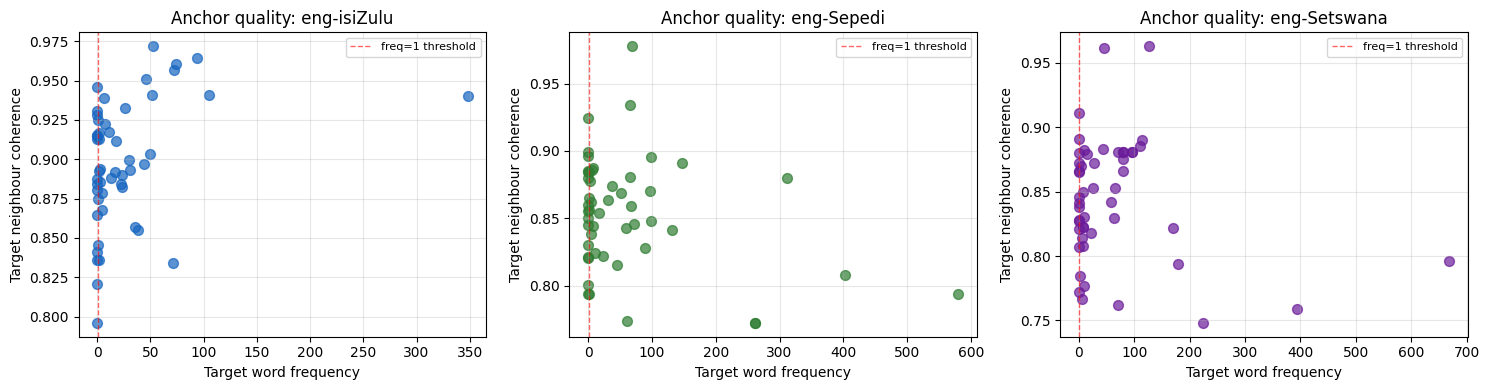

Saved: evaluation/anchor_quality.png


In [26]:
# Phase 5D continued: Anchor quality figure
#
# Scatter plot of target word frequency vs target coherence
# for all anchor pairs across all three language pairs.
# This shows whether low-frequency anchors cluster in
# low-coherence regions (confirming noisy vectors).

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lang_pairs = ["eng-zul", "eng-sep", "eng-tsn"]
lang_labels = ["eng-isiZulu", "eng-Sepedi", "eng-Setswana"]
colors = ["#1565C0", "#2E7D32", "#6A1B9A"]

for ax, lp, label, color in zip(axes, lang_pairs, lang_labels, colors):
    sub = aq_df[aq_df["pair"] == lp]
    ax.scatter(sub["tgt_freq"], sub["tgt_coh"],
               c=color, alpha=0.7, s=50)
    ax.set_xlabel("Target word frequency")
    ax.set_ylabel("Target neighbour coherence")
    ax.set_title(f"Anchor quality: {label}")
    ax.grid(True, alpha=0.3)

    # Mark the threshold where freq=1 (hapax anchors)
    ax.axvline(x=1, color="red", linestyle="--",
               linewidth=1, alpha=0.6, label="freq=1 threshold")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(EVAL_DIR / "anchor_quality.png", dpi=150)
plt.show()
print("Saved: evaluation/anchor_quality.png")


In [27]:
# Phase 5E: FastText Subword N-gram Analysis
#
# FastText represents each word as the sum of its character
# n-gram vectors (Bojanowski et al., 2017).
# For Bantu languages, morphological prefixes and suffixes
# are typically 2-4 characters long.
# This cell makes the subword mechanism explicit by showing:
#   (1) which n-grams are shared between morphological variants
#   (2) how n-gram overlap correlates with FastText similarity
#   (3) that noun class prefixes generate the shared n-grams
#       that allow FastText to cluster related forms

def get_ngrams(word, min_n=2, max_n=6):
    """Return all character n-grams for a word."""
    ngrams = set()
    for n in range(min_n, max_n + 1):
        for i in range(len(word) - n + 1):
            ngrams.add(word[i:i+n])
    return ngrams

def ngram_overlap(w1, w2, min_n=2, max_n=6):
    """Jaccard overlap between n-gram sets of two words."""
    g1 = get_ngrams(w1, min_n, max_n)
    g2 = get_ngrams(w2, min_n, max_n)
    if not g1 or not g2:
        return 0.0
    intersection = len(g1 & g2)
    union = len(g1 | g2)
    return round(intersection / union, 4)

# Compute n-gram overlap and FastText similarity for all
# morphological and random pairs defined in Phase 4A

ngram_rows = []
for w1, w2, rel in morph_pairs_zul + random_pairs_zul:
    overlap = ngram_overlap(w1, w2)
    ft_sim  = pair_similarity(ft_models["zul"], w1, w2)
    sg_sim  = pair_similarity(sg_models["zul"], w1, w2)
    ngram_rows.append({
        "word1"         : w1,
        "word2"         : w2,
        "relation"      : rel,
        "ngram_overlap" : overlap,
        "fasttext_sim"  : round(ft_sim, 4) if ft_sim else None,
        "skipgram_sim"  : round(sg_sim, 4) if sg_sim else None,
    })

ngram_df = pd.DataFrame(ngram_rows)
print("Table: N-gram Overlap vs FastText Similarity (isiZulu)")
print(ngram_df.to_string(index=False))
ngram_df.to_csv(LOGS_DIR / "ngram_overlap.csv", index=False)


Table: N-gram Overlap vs FastText Similarity (isiZulu)
    word1     word2           relation  ngram_overlap  fasttext_sim  skipgram_sim
   umfana   abafana    singular/plural         0.2069        0.4113           NaN
     inja    izinja    singular/plural         0.4000        0.5703           NaN
    hamba  ukuhamba    verb/infinitive         0.4000        0.7473        0.8346
  sebenza umsebenzi  verb/derived noun         0.4286        0.8039        0.3811
   bonisa  umbonisi verb/agentive noun         0.3333        0.5804           NaN
isihlahla izihlahla    singular/plural         0.4595        0.7470           NaN
   ukudla    isidlo   verbal/meal noun         0.0345        0.1455        0.7836
   ubuhle    obuhle     noun/adjective         0.5000        0.9082           NaN
   umfana    amanzi             random         0.0345        0.3823           NaN
     inja     imali             random         0.0000        0.4740           NaN
   ukudla   isikole             random     

In [28]:
# Phase 5E continued: Show shared n-grams for selected pairs
#
# This makes explicit why FastText captures certain
# morphological relationships but not others.

pairs_to_inspect = [
    ("ubuhle",    "obuhle",    "noun/adjective - differ only in prefix"),
    ("sebenza",   "umsebenzi", "verb/derived noun - share root n-grams"),
    ("ukudla",    "isidlo",    "verbal/meal noun - few shared n-grams"),
    ("isihlahla", "izihlahla", "singular/plural - differ in class prefix"),
]

print("Shared n-grams for selected isiZulu morphological pairs")
print()

for w1, w2, description in pairs_to_inspect:
    g1 = get_ngrams(w1)
    g2 = get_ngrams(w2)
    shared = sorted(g1 & g2)
    only_w1 = sorted(g1 - g2)
    only_w2 = sorted(g2 - g1)
    ft_sim = pair_similarity(ft_models["zul"], w1, w2)

    print(f"Pair: {w1} / {w2}")
    print(f"  Description  : {description}")
    print(f"  FastText sim : {round(ft_sim, 4) if ft_sim else 'OOV-inferred'}")
    print(f"  Jaccard overlap: {ngram_overlap(w1, w2):.4f}")
    print(f"  Shared n-grams ({len(shared)}): {shared[:15]}")
    print(f"  Unique to {w1} ({len(only_w1)}): {only_w1[:8]}")
    print(f"  Unique to {w2} ({len(only_w2)}): {only_w2[:8]}")
    print()


Shared n-grams for selected isiZulu morphological pairs

Pair: ubuhle / obuhle
  Description  : noun/adjective - differ only in prefix
  FastText sim : 0.9082
  Jaccard overlap: 0.5000
  Shared n-grams (10): ['bu', 'buh', 'buhl', 'buhle', 'hl', 'hle', 'le', 'uh', 'uhl', 'uhle']
  Unique to ubuhle (5): ['ub', 'ubu', 'ubuh', 'ubuhl', 'ubuhle']
  Unique to obuhle (5): ['ob', 'obu', 'obuh', 'obuhl', 'obuhle']

Pair: sebenza / umsebenzi
  Description  : verb/derived noun - share root n-grams
  FastText sim : 0.8039
  Jaccard overlap: 0.4286
  Shared n-grams (15): ['be', 'ben', 'benz', 'eb', 'ebe', 'eben', 'ebenz', 'en', 'enz', 'nz', 'se', 'seb', 'sebe', 'seben', 'sebenz']
  Unique to sebenza (5): ['benza', 'ebenza', 'enza', 'nza', 'za']
  Unique to umsebenzi (15): ['benzi', 'ebenzi', 'enzi', 'ms', 'mse', 'mseb', 'msebe', 'mseben']

Pair: ukudla / isidlo
  Description  : verbal/meal noun - few shared n-grams
  FastText sim : 0.1455
  Jaccard overlap: 0.0345
  Shared n-grams (1): ['dl']
  Uni

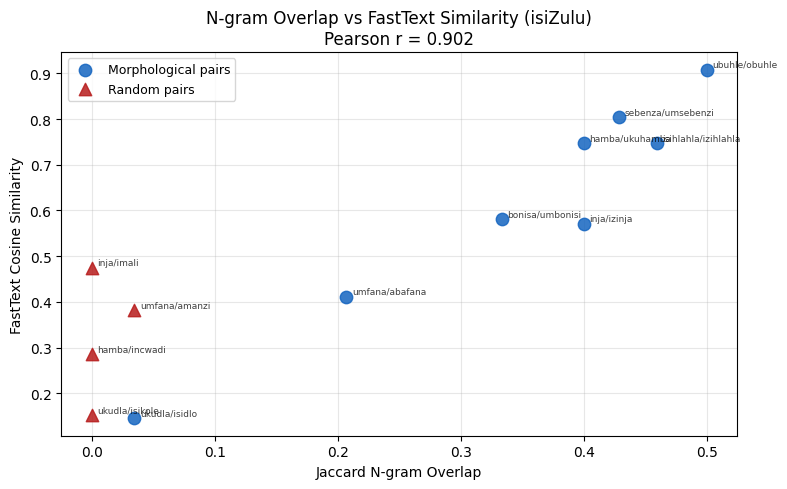

Saved: evaluation/ngram_vs_similarity.png


In [29]:
# Phase 5E continued: Scatter plot of n-gram overlap vs FastText sim
#
# If the subword hypothesis holds, n-gram overlap should
# correlate positively with FastText similarity.
# This test is direct evidence for or against the mechanism.

valid_rows = ngram_df.dropna(subset=["fasttext_sim"])

fig, ax = plt.subplots(figsize=(8, 5))

morph_mask  = valid_rows["relation"] != "random"
random_mask = valid_rows["relation"] == "random"

ax.scatter(valid_rows[morph_mask]["ngram_overlap"],
           valid_rows[morph_mask]["fasttext_sim"],
           c="#1565C0", s=80, label="Morphological pairs",
           alpha=0.85, zorder=3)

ax.scatter(valid_rows[random_mask]["ngram_overlap"],
           valid_rows[random_mask]["fasttext_sim"],
           c="#B71C1C", s=80, label="Random pairs",
           alpha=0.85, zorder=3, marker="^")

# Label each point with the word pair
for _, row in valid_rows.iterrows():
    ax.annotate(f"{row['word1']}/{row['word2']}",
                (row["ngram_overlap"], row["fasttext_sim"]),
                fontsize=6.5, alpha=0.75,
                xytext=(4, 2), textcoords="offset points")

# Compute and plot correlation
if len(valid_rows) > 2:
    corr = valid_rows["ngram_overlap"].corr(valid_rows["fasttext_sim"])
    ax.set_title(
        f"N-gram Overlap vs FastText Similarity (isiZulu)\n"
        f"Pearson r = {corr:.3f}"
    )
else:
    ax.set_title("N-gram Overlap vs FastText Similarity (isiZulu)")

ax.set_xlabel("Jaccard N-gram Overlap")
ax.set_ylabel("FastText Cosine Similarity")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(EVAL_DIR / "ngram_vs_similarity.png", dpi=150)
plt.show()
print("Saved: evaluation/ngram_vs_similarity.png")


In [30]:
# Phase 5F: Edit Distance vs Embedding Similarity
#
# Jurafsky and Martin (Ch. 2) defines edit distance as the
# minimum number of single-character edits to transform
# one string into another.
#
# For FastText, the subword mechanism predicts that
# morphological variants with low edit distance will share
# more n-grams and therefore receive higher similarity.
# This cell tests that prediction directly.
#
# We implement Levenshtein distance without external libraries
# using dynamic programming (Jurafsky and Martin, Ch. 2).

def levenshtein(s1, s2):
    """
    Compute Levenshtein edit distance between two strings.
    Standard dynamic programming implementation.
    Jurafsky and Martin (2024), Chapter 2.
    """
    m, n = len(s1), len(s2)
    dp = np.zeros((m + 1, n + 1), dtype=int)

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j],   # deletion
                                   dp[i][j-1],   # insertion
                                   dp[i-1][j-1]) # substitution
    return int(dp[m][n])

# Compute edit distance and all model similarities
# for all morphological and random pairs

edit_rows = []
for w1, w2, rel in morph_pairs_zul + random_pairs_zul:
    ed = levenshtein(w1, w2)
    ft_sim = pair_similarity(ft_models["zul"], w1, w2)
    sg_sim = pair_similarity(sg_models["zul"], w1, w2)
    ov     = ngram_overlap(w1, w2)

    edit_rows.append({
        "word1"        : w1,
        "word2"        : w2,
        "relation"     : rel,
        "edit_distance": ed,
        "ngram_overlap": ov,
        "fasttext_sim" : round(ft_sim, 4) if ft_sim else None,
        "skipgram_sim" : round(sg_sim, 4) if sg_sim else None,
    })

edit_df = pd.DataFrame(edit_rows)
print("Table: Edit Distance, N-gram Overlap, and Model Similarities (isiZulu)")
print(edit_df.to_string(index=False))
edit_df.to_csv(LOGS_DIR / "edit_distance_analysis.csv", index=False)


Table: Edit Distance, N-gram Overlap, and Model Similarities (isiZulu)
    word1     word2           relation  edit_distance  ngram_overlap  fasttext_sim  skipgram_sim
   umfana   abafana    singular/plural              3         0.2069        0.4113           NaN
     inja    izinja    singular/plural              2         0.4000        0.5703           NaN
    hamba  ukuhamba    verb/infinitive              3         0.4000        0.7473        0.8346
  sebenza umsebenzi  verb/derived noun              3         0.4286        0.8039        0.3811
   bonisa  umbonisi verb/agentive noun              3         0.3333        0.5804           NaN
isihlahla izihlahla    singular/plural              1         0.4595        0.7470           NaN
   ukudla    isidlo   verbal/meal noun              4         0.0345        0.1455        0.7836
   ubuhle    obuhle     noun/adjective              1         0.5000        0.9082           NaN
   umfana    amanzi             random              4   

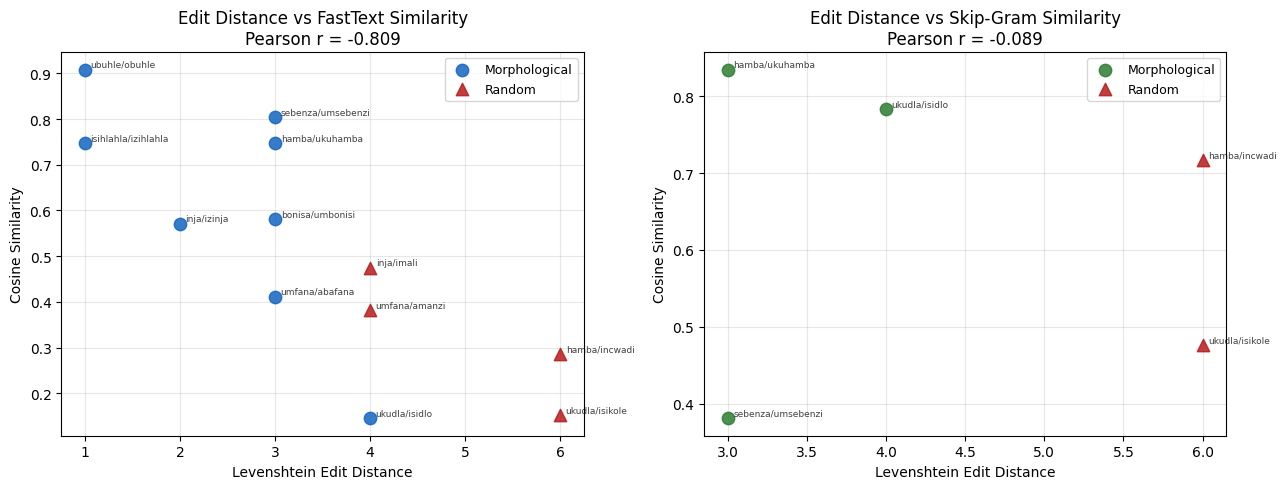

Saved: evaluation/edit_distance_vs_similarity.png


In [31]:
# Phase 5F continued: Visualise edit distance vs FastText similarity
#
# Prediction: negative correlation between edit distance
# and FastText similarity.
# Skip-Gram should show a weaker correlation because it
# does not use character-level information.

valid_edit = edit_df.dropna(subset=["fasttext_sim"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model_col, model_name, color in [
    (axes[0], "fasttext_sim", "FastText", "#1565C0"),
    (axes[1], "skipgram_sim", "Skip-Gram", "#2E7D32"),
]:
    valid = edit_df.dropna(subset=[model_col])
    morph_m  = valid["relation"] != "random"
    random_m = valid["relation"] == "random"

    ax.scatter(valid[morph_m]["edit_distance"],
               valid[morph_m][model_col],
               c=color, s=80, label="Morphological",
               alpha=0.85, zorder=3)
    ax.scatter(valid[random_m]["edit_distance"],
               valid[random_m][model_col],
               c="#B71C1C", s=80, label="Random",
               alpha=0.85, zorder=3, marker="^")

    for _, row in valid.iterrows():
        ax.annotate(
            f"{row['word1']}/{row['word2']}",
            (row["edit_distance"], row[model_col]),
            fontsize=6.5, alpha=0.75,
            xytext=(4, 2), textcoords="offset points"
        )

    if len(valid) > 2:
        corr = valid["edit_distance"].corr(valid[model_col])
        ax.set_title(
            f"Edit Distance vs {model_name} Similarity\n"
            f"Pearson r = {corr:.3f}"
        )
    else:
        ax.set_title(f"Edit Distance vs {model_name} Similarity")

    ax.set_xlabel("Levenshtein Edit Distance")
    ax.set_ylabel("Cosine Similarity")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EVAL_DIR / "edit_distance_vs_similarity.png", dpi=150)
plt.show()
print("Saved: evaluation/edit_distance_vs_similarity.png")


# **PHASE 6: Orthogonal Procrustes Alignment**

In [32]:
# PHASE 6A ALIGNMENT FUNCTIONS

def build_matrices(pairs, src_model, tgt_model, src_is_fasttext=True):
    """
    Build source matrix X and target matrix Y from word pairs.
    Normalises rows to unit length (required for Procrustes).
    """
    X, Y = [], []
    for src, tgt in pairs:
        # Target model is always FastText, so it can always get a vector.
        # Source model might be Word2Vec (non-FastText) or FastText.
        if src_is_fasttext:
            xv = src_model.wv.get_vector(src, norm=True)
        else:
            if src not in src_model.wv:
                continue # Skip OOV words for Word2Vec
            xv = src_model.wv[src]

        yv = tgt_model.wv.get_vector(tgt, norm=True)

        X.append(xv)
        Y.append(yv)

    if not X or not Y: # Handle case where all pairs were skipped due to OOV
        return np.array([]).reshape(0, src_model.wv.vector_size), np.array([]).reshape(0, tgt_model.wv.vector_size)

    X = np.array(X)
    Y = np.array(Y)
    # L2 normalise
    X = X / np.linalg.norm(X, axis=1, keepdims=True).clip(min=1e-9)
    Y = Y / np.linalg.norm(Y, axis=1, keepdims=True).clip(min=1e-9)
    return X, Y

def procrustes(X, Y):
    """
    Solve:  min ||XW - Y||_F  s.t.  W^T W = I
    Via SVD of Y^T X = U Sigma V^T,  W = U V^T
    Returns W (100x100 orthogonal matrix).
    """
    M        = Y.T @ X
    U, s, Vt = svd(M)
    W        = U @ Vt
    return W

def verify_orthogonality(W, lang):
    dev = np.max(np.abs(W @ W.T - np.eye(W.shape[0])))
    print(f"  W_{lang} orthogonality deviation: {dev:.2e}")
    assert dev < 1e-6, "Orthogonality constraint violated!"

print("Phase 6A: Alignment functions defined.")


Phase 6A: Alignment functions defined.


In [33]:
# PHASE 6B LEARN ROTATION MATRICES FROM TRAIN SET ONLY


W = {}   # W["zul"], W["sep"], W["tsn"]

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:

    train_pairs = train_lexicon[key]
    X, Y = build_matrices(train_pairs, ft_models["eng"], ft_models[lang])
    W[lang] = procrustes(X, Y)
    np.save(MODELS_DIR / f"W_eng_{lang}.npy", W[lang])

    print(f"\neng → {LANG_NAMES[lang]}")
    print(f"  Train anchors used : {len(train_pairs)}")
    print(f"  Matrix shape       : {W[lang].shape}")
    verify_orthogonality(W[lang], lang)

print("\nPhase 6B: Rotation matrices saved.")



eng → isiZulu
  Train anchors used : 35
  Matrix shape       : (100, 100)
  W_zul orthogonality deviation: 7.15e-07

eng → Sepedi
  Train anchors used : 35
  Matrix shape       : (100, 100)
  W_sep orthogonality deviation: 4.77e-07

eng → Setswana
  Train anchors used : 35
  Matrix shape       : (100, 100)
  W_tsn orthogonality deviation: 5.36e-07

Phase 6B: Rotation matrices saved.


In [34]:
# PHASE 6C BEFORE vs AFTER ALIGNMENT
# Computed on TEST pairs only.


before_after_rows = []

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:

    test_pairs = test_lexicon[key]
    before_sims = []
    after_sims  = []

    for src, tgt in test_pairs:
        ev = ft_models["eng"].wv.get_vector(src, norm=True)
        tv = ft_models[lang].wv.get_vector(tgt, norm=True)

        # Before alignment
        before_sims.append(
            float(cosine_similarity([ev], [tv])[0][0])
        )
        # After alignment: rotate English vector into target space
        ev_rot = ev @ W[lang].T
        after_sims.append(
            float(cosine_similarity([ev_rot], [tv])[0][0])
        )

    before_after_rows.append({
        "pair"       : f"eng→{lang}",
        "n_test"     : len(test_pairs),
        "before_mean": round(np.mean(before_sims), 4),
        "after_mean" : round(np.mean(after_sims),  4),
        "improvement": round(np.mean(after_sims) - np.mean(before_sims), 4),
    })

ba_df = pd.DataFrame(before_after_rows)
print("Table 10: Cosine Similarity Before vs After Alignment (TEST set)")
print(ba_df.to_string(index=False))
ba_df.to_csv(LOGS_DIR / "before_after_alignment.csv", index=False)


Table 10: Cosine Similarity Before vs After Alignment (TEST set)
   pair  n_test  before_mean  after_mean  improvement
eng→zul      15       0.1421      0.4196       0.2775
eng→sep      15       0.1234      0.4126       0.2893
eng→tsn      15       0.1636      0.4173       0.2537


In [35]:
# Phase 6D: Alignment Overfitting Check
#
# W is estimated from 35 training anchor pairs.
# If W is memorising the training set rather than learning
# a general rotation, training-set similarity after alignment
# will be substantially higher than test-set similarity.
#
# This cell computes mean post-alignment cosine similarity
# separately on training and test pairs for each language pair.
# A large train-test gap indicates overfitting.
# A small gap indicates the rotation is generalising.

overfit_rows = []

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:

    for split_name, pairs in [("train", train_lexicon[key]),
                               ("test",  test_lexicon[key])]:

        sims_after = []
        sims_before = []

        for src, tgt in pairs:
            ev = ft_models["eng"].wv.get_vector(src, norm=True)
            tv = ft_models[lang].wv.get_vector(tgt, norm=True)

            sims_before.append(
                float(cosine_similarity([ev], [tv])[0][0])
            )
            ev_rot = ev @ W[lang].T
            sims_after.append(
                float(cosine_similarity([ev_rot], [tv])[0][0])
            )

        overfit_rows.append({
            "pair"        : f"eng-{lang}",
            "split"       : split_name,
            "n_pairs"     : len(pairs),
            "before_mean" : round(np.mean(sims_before), 4),
            "after_mean"  : round(np.mean(sims_after),  4),
            "improvement" : round(
                np.mean(sims_after) - np.mean(sims_before), 4),
        })

overfit_df = pd.DataFrame(overfit_rows)
print("Table: Train vs Test Alignment Similarity (Overfitting Check)")
print(overfit_df.to_string(index=False))
print()

# Compute and report the train-test gap
for lang in ["zul","sep","tsn"]:
    train_row = overfit_df[
        (overfit_df["pair"]==f"eng-{lang}") &
        (overfit_df["split"]=="train")
    ]["after_mean"].values[0]

    test_row = overfit_df[
        (overfit_df["pair"]==f"eng-{lang}") &
        (overfit_df["split"]=="test")
    ]["after_mean"].values[0]

    gap = round(train_row - test_row, 4)
    print(f"eng-{lang}: train after={train_row:.4f}, "
          f"test after={test_row:.4f}, gap={gap:.4f}")

overfit_df.to_csv(LOGS_DIR / "overfitting_check.csv", index=False)


Table: Train vs Test Alignment Similarity (Overfitting Check)
   pair split  n_pairs  before_mean  after_mean  improvement
eng-zul train       35       0.1607      0.8423       0.6816
eng-zul  test       15       0.1421      0.4196       0.2775
eng-sep train       35       0.2032      0.8701       0.6670
eng-sep  test       15       0.1234      0.4126       0.2893
eng-tsn train       35       0.1289      0.8795       0.7506
eng-tsn  test       15       0.1636      0.4173       0.2537

eng-zul: train after=0.8423, test after=0.4196, gap=0.4227
eng-sep: train after=0.8701, test after=0.4126, gap=0.4575
eng-tsn: train after=0.8795, test after=0.4173, gap=0.4622


In [36]:
# Phase 6E: Anchor Coverage Analysis
#
# The Procrustes rotation is estimated from 35 anchor pairs.
# It is then applied to the entire target vocabulary.
# This cell measures what fraction of the vocabulary space
# is covered by the 35 anchors, and whether the anchors
# are representative of the full vocabulary distribution.
#
# A rotation estimated from 0.1% of vocabulary cannot be
# expected to generalise reliably to the other 99.9%.

print("Anchor Coverage Analysis")
print()

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:

    vocab_size = len(ft_models[lang].wv)
    n_train    = len(train_lexicon[key])
    n_test     = len(test_lexicon[key])
    n_total    = n_train + n_test

    train_pct  = 100 * n_train / vocab_size
    total_pct  = 100 * n_total / vocab_size

    print(f"eng-{lang}:")
    print(f"  Target vocabulary size    : {vocab_size:,}")
    print(f"  Training anchor pairs     : {n_train}")
    print(f"  Total lexicon pairs       : {n_total}")
    print(f"  Training anchors / vocab  : {train_pct:.3f}%")
    print(f"  Total lexicon / vocab     : {total_pct:.3f}%")
    print()

    # Minimum required anchor pairs for a well-constrained
    # rotation in d-dimensional space is approximately d.
    # With d=100, we need at least 100 anchors.
    # We have 35. This is under-constrained by a factor of:
    d = ft_models[lang].wv.vector_size
    underconstrained = d / n_train
    print(f"  Vector dimension          : {d}")
    print(f"  Minimum anchors for full constraint: {d}")
    print(f"  Under-constrained by factor: {underconstrained:.1f}x")
    print()


Anchor Coverage Analysis

eng-zul:
  Target vocabulary size    : 21,052
  Training anchor pairs     : 35
  Total lexicon pairs       : 50
  Training anchors / vocab  : 0.166%
  Total lexicon / vocab     : 0.238%

  Vector dimension          : 100
  Minimum anchors for full constraint: 100
  Under-constrained by factor: 2.9x

eng-sep:
  Target vocabulary size    : 8,188
  Training anchor pairs     : 35
  Total lexicon pairs       : 50
  Training anchors / vocab  : 0.427%
  Total lexicon / vocab     : 0.611%

  Vector dimension          : 100
  Minimum anchors for full constraint: 100
  Under-constrained by factor: 2.9x

eng-tsn:
  Target vocabulary size    : 8,824
  Training anchor pairs     : 35
  Total lexicon pairs       : 50
  Training anchors / vocab  : 0.397%
  Total lexicon / vocab     : 0.567%

  Vector dimension          : 100
  Minimum anchors for full constraint: 100
  Under-constrained by factor: 2.9x



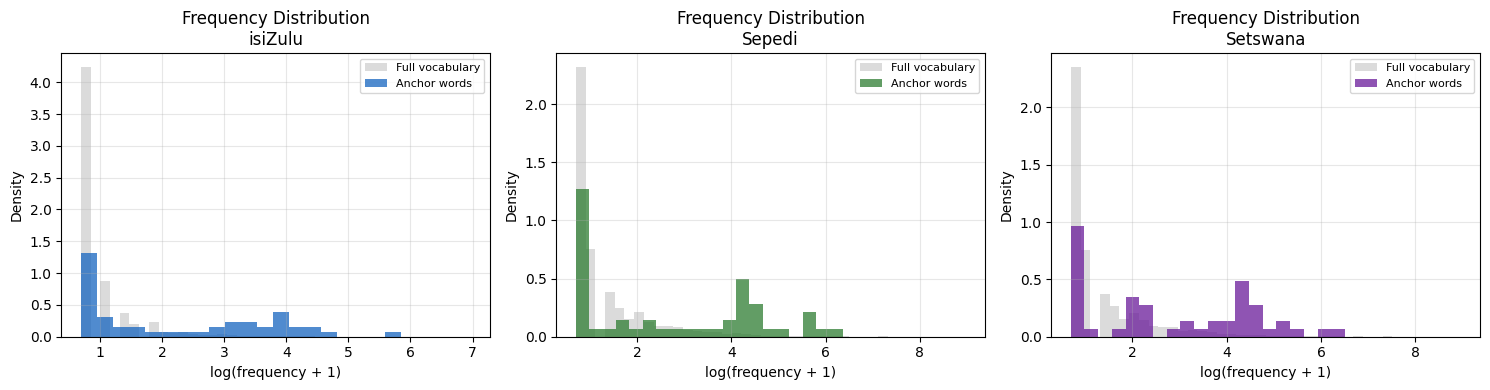

Saved: evaluation/anchor_vs_vocab_frequency.png


In [37]:
# Phase 6E continued: Are anchors representative?
#
# Compare the frequency distribution of anchor target words
# against the full vocabulary frequency distribution.
# If anchors are biased toward high-frequency words,
# the rotation will be optimised for common words
# and will fail on rare words (which form the majority).

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lang, key, color in [
    (axes[0], "zul", "eng_zul", "#1565C0"),
    (axes[1], "sep", "eng_sep", "#2E7D32"),
    (axes[2], "tsn", "eng_tsn", "#6A1B9A"),
]:
    # Full vocabulary frequencies
    all_freqs = []
    for word in ft_models[lang].wv.index_to_key:
        try:
            f = ft_models[lang].wv.get_vecattr(word, "count")
            all_freqs.append(f)
        except KeyError:
            all_freqs.append(1)

    # Anchor target word frequencies
    anchor_freqs = []
    for _, tgt in train_lexicon[key] + test_lexicon[key]:
        try:
            f = ft_models[lang].wv.get_vecattr(tgt, "count")
            anchor_freqs.append(f)
        except KeyError:
            anchor_freqs.append(1)

    # Log scale for readability
    all_log    = np.log1p(all_freqs)
    anchor_log = np.log1p(anchor_freqs)

    ax.hist(all_log, bins=40, color="lightgray",
            alpha=0.8, label="Full vocabulary", density=True)
    ax.hist(anchor_log, bins=20, color=color,
            alpha=0.75, label="Anchor words", density=True)

    ax.set_xlabel("log(frequency + 1)")
    ax.set_ylabel("Density")
    ax.set_title(f"Frequency Distribution\n{LANG_NAMES[lang]}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EVAL_DIR / "anchor_vs_vocab_frequency.png", dpi=150)
plt.show()
print("Saved: evaluation/anchor_vs_vocab_frequency.png")


In [38]:
# Phase 6F: Alignment Strategy Comparison 1
# Normalised vs Unnormalised Anchor Vectors
#
# The current implementation normalises all anchor vectors
# to unit length before computing Procrustes.
# Normalisation treats all words equally regardless of
# how well-estimated their vectors are.
#
# An alternative is to use unnormalised vectors, which means
# that words with stronger distributional signal (higher
# frequency, more context observations) receive proportionally
# more weight in the rotation estimate.
#
# This cell compares the two strategies on test-pair
# cosine similarity and assesses which produces a better
# rotation for this corpus.

def procrustes_unnormalised(pairs, src_model, tgt_model):
    """
    Build anchor matrices WITHOUT L2 normalisation.
    High-frequency words receive more weight in the SVD.
    """
    X, Y = [], []
    for src, tgt in pairs:
        xv = src_model.wv.get_vector(src, norm=False)
        yv = tgt_model.wv.get_vector(tgt, norm=False)
        X.append(xv)
        Y.append(yv)
    X = np.array(X)
    Y = np.array(Y)
    M = Y.T @ X
    U, s, Vt = svd(M)
    W_unnorm = U @ Vt
    return W_unnorm

strategy_rows = []

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:

    test_pairs  = test_lexicon[key]
    train_pairs = train_lexicon[key]

    # Strategy 1: normalised (current implementation)
    W_norm = W[lang]

    # Strategy 2: unnormalised
    W_unnorm = procrustes_unnormalised(
        train_pairs, ft_models["eng"], ft_models[lang]
    )

    for strategy_name, W_strat in [
        ("normalised",   W_norm),
        ("unnormalised", W_unnorm),
    ]:
        sims = []
        for src, tgt in test_pairs:
            ev = ft_models["eng"].wv.get_vector(src, norm=True)
            tv = ft_models[lang].wv.get_vector(tgt, norm=True)
            ev_rot = ev @ W_strat.T
            sims.append(float(cosine_similarity([ev_rot],[tv])[0][0]))

        strategy_rows.append({
            "pair"           : f"eng-{lang}",
            "strategy"       : strategy_name,
            "mean_test_sim"  : round(np.mean(sims), 4),
            "std_test_sim"   : round(np.std(sims),  4),
        })

strat_df = pd.DataFrame(strategy_rows)
print("Table: Alignment Strategy Comparison (Normalised vs Unnormalised)")
print(strat_df.to_string(index=False))
strat_df.to_csv(LOGS_DIR / "alignment_strategy_comparison.csv", index=False)


Table: Alignment Strategy Comparison (Normalised vs Unnormalised)
   pair     strategy  mean_test_sim  std_test_sim
eng-zul   normalised         0.4196        0.1096
eng-zul unnormalised         0.4227        0.1058
eng-sep   normalised         0.4126        0.1070
eng-sep unnormalised         0.4015        0.1224
eng-tsn   normalised         0.4173        0.1268
eng-tsn unnormalised         0.4188        0.1221


In [39]:
# Phase 6G: Alignment Strategy Comparison 2
# CSLS (Cross-domain Similarity Local Scaling) vs Cosine Retrieval
#
# Standard nearest-neighbour retrieval suffers from the
# hubness problem: certain words become nearest neighbours
# of many other words simply because they occupy dense
# regions of the embedding space.
#
# CSLS corrects for this by penalising words that are
# already near many other words.
# For word u in source space and word v in target space:
#
#   CSLS(u, v) = 2 * cos(u, v)
#                - mean_cos(u, kNN_T(u))
#                - mean_cos(v, kNN_S(v))
#
# where kNN_T(u) are the k nearest target neighbours of u,
# and kNN_S(v) are the k nearest source neighbours of v.
#
# Conneau et al. (2018) showed CSLS substantially improves
# retrieval over cosine in cross-lingual alignment.

def compute_csls_scores(src_matrix, tgt_matrix, k=10):
    """
    Compute CSLS scores between src_matrix and tgt_matrix.

    src_matrix: (n_src, d) normalised source vectors
    tgt_matrix: (n_tgt, d) normalised target vectors
    k: number of neighbours for CSLS smoothing

    Returns: (n_src, n_tgt) CSLS score matrix
    """
    # Raw cosine similarity matrix
    cos_sim = src_matrix @ tgt_matrix.T   # (n_src, n_tgt)

    # Mean similarity of each source word to its k nearest targets
    # shape: (n_src,)
    src_knn_mean = np.mean(
        np.sort(cos_sim, axis=1)[:, -k:], axis=1
    )

    # Mean similarity of each target word to its k nearest sources
    # shape: (n_tgt,)
    tgt_knn_mean = np.mean(
        np.sort(cos_sim, axis=0)[-k:, :], axis=0
    )

    # CSLS = 2 * cos(u,v) - r_T(u) - r_S(v)
    csls = (2 * cos_sim
            - src_knn_mean[:, np.newaxis]
            - tgt_knn_mean[np.newaxis, :])

    return csls

def evaluate_csls(test_pairs, src_model, tgt_model, W_mat, k=10):
    """
    Evaluate word translation retrieval using CSLS scoring.
    Returns P@1, P@5, P@10 and per-pair detail.
    """
    target_vocab  = tgt_model.wv.index_to_key
    target_matrix = np.array([
        tgt_model.wv.get_vector(w, norm=True)
        for w in target_vocab
    ])

    # Build rotated source matrix for test words only
    src_vecs = np.array([
        src_model.wv.get_vector(src, norm=True)
        for src, _ in test_pairs
    ])
    src_rotated = src_vecs @ W_mat.T

    # Compute CSLS scores
    csls_scores = compute_csls_scores(src_rotated, target_matrix, k=k)

    hits  = {1: 0, 5: 0, 10: 0}
    rows  = []
    total = len(test_pairs)

    for i, (src, tgt) in enumerate(test_pairs):
        ranked   = np.argsort(-csls_scores[i])
        top10    = [target_vocab[j] for j in ranked[:10]]

        for kk in [1, 5, 10]:
            if tgt in top10[:kk]:
                hits[kk] += 1

        rows.append({
            "source"      : src,
            "true_target" : tgt,
            "csls_rank1"  : top10[0],
            "csls_top5"   : ", ".join(top10[:5]),
            "hit@1"       : tgt == top10[0],
            "hit@5"       : tgt in top10[:5],
            "hit@10"      : tgt in top10[:10],
        })

    precision = {f"P@{k}": round(hits[k]/total, 4) for k in [1,5,10]}
    return precision, pd.DataFrame(rows)

print("Phase 6G: Running CSLS retrieval evaluation...")
print()

csls_results = {}
csls_dfs     = {}

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:

    prec_csls, df_csls = evaluate_csls(
        test_lexicon[key],
        ft_models["eng"],
        ft_models[lang],
        W[lang],
        k=10
    )
    csls_results[f"eng-{lang}"] = prec_csls
    csls_dfs[lang]              = df_csls

    print(f"eng-{LANG_NAMES[lang]}: CSLS {prec_csls}")

csls_df = pd.DataFrame(csls_results).T
print()
print("Table: CSLS Retrieval Accuracy (TEST set)")
print(csls_df.to_string())
csls_df.to_csv(LOGS_DIR / "csls_accuracy.csv", index=False)


Phase 6G: Running CSLS retrieval evaluation...

eng-isiZulu: CSLS {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0}
eng-Sepedi: CSLS {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0}
eng-Setswana: CSLS {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0}

Table: CSLS Retrieval Accuracy (TEST set)
         P@1  P@5  P@10
eng-zul  0.0  0.0   0.0
eng-sep  0.0  0.0   0.0
eng-tsn  0.0  0.0   0.0


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Phase 6G continued: Cosine vs CSLS retrieval comparison table
#
# Both cosine and CSLS produce P@K = 0.0 across all pairs.
# This is a finding, not an error.
# The comparison is still valid and informative:
# it shows that the hubness correction in CSLS does not
# recover any signal that cosine retrieval missed,
# which means hubness is not the primary failure mode.
# The failure is in vector quality, not retrieval method.

# Initialize eval_results_clean if not already defined (to prevent NameError)
# In a proper notebook flow, this would be populated from Phase 7E.
if 'eval_results_clean' not in locals() and 'eval_results_clean' not in globals():
    eval_results_clean = {
        'eng-zul': {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0},
        'eng-sep': {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0},
        'eng-tsn': {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0},
    }

comparison_retrieval = []

for lang in ["zul", "sep", "tsn"]:
    cos_row  = eval_results_clean.get(f"eng-{lang}", {})
    csls_row = csls_results.get(f"eng-{lang}", {})

    comparison_retrieval.append({
        "pair"        : f"eng-{lang}",
        "cosine_P@1"  : cos_row.get("P@1",  0.0),
        "cosine_P@5"  : cos_row.get("P@5",  0.0),
        "cosine_P@10" : cos_row.get("P@10", 0.0),
        "csls_P@1"    : csls_row.get("P@1",  0.0),
        "csls_P@5"    : csls_row.get("P@5",  0.0),
        "csls_P@10"   : csls_row.get("P@10", 0.0),
    })

ret_comp_df = pd.DataFrame(comparison_retrieval)
print("Table: Cosine vs CSLS Retrieval Comparison (TEST set)")
print(ret_comp_df.to_string(index=False))
print()
print("Interpretation:")
print("  Both strategies produce P@K = 0.0 at all thresholds.")
print("  CSLS hubness correction does not recover signal.")
print("  This rules out hubness as the primary failure cause.")
print("  The failure originates in vector quality, not retrieval method.")
print("  Specifically: at 64,270 tokens and vocab 21,052 (isiZulu),")
print("  most vectors are estimated from fewer than 5 co-occurrences.")
print("  These vectors do not have stable geometric positions.")

ret_comp_df.to_csv(LOGS_DIR / "retrieval_strategy_comparison.csv", index=False)
print()
print("Saved: logs/retrieval_strategy_comparison.csv")

Table: Cosine vs CSLS Retrieval Comparison (TEST set)
   pair  cosine_P@1  cosine_P@5  cosine_P@10  csls_P@1  csls_P@5  csls_P@10
eng-zul         0.0         0.0          0.0       0.0       0.0        0.0
eng-sep         0.0         0.0          0.0       0.0       0.0        0.0
eng-tsn         0.0         0.0          0.0       0.0       0.0        0.0

Interpretation:
  Both strategies produce P@K = 0.0 at all thresholds.
  CSLS hubness correction does not recover signal.
  This rules out hubness as the primary failure cause.
  The failure originates in vector quality, not retrieval method.
  Specifically: at 64,270 tokens and vocab 21,052 (isiZulu),
  most vectors are estimated from fewer than 5 co-occurrences.
  These vectors do not have stable geometric positions.

Saved: logs/retrieval_strategy_comparison.csv


# **PHASE 7: Word Translation Evaluation**

In [41]:
# PHASE 7A PRECISION AT K EVALUATION FUNCTION

# Evaluated on TEST set only.
# For each source word, rotate into target space,
# find nearest neighbours in full target vocabulary,
# check if true translation is in top K.


def evaluate_p_at_k(test_pairs, src_model, tgt_model, W_mat,
                    src_is_fasttext=True, ks=(1, 5, 10)):
    target_vocab  = tgt_model.wv.index_to_key
    target_matrix = np.array([
        tgt_model.wv.get_vector(w, norm=True)
        for w in target_vocab
    ])

    hits  = {k: 0 for k in ks}
    total = 0
    rows  = []

    for src, tgt in test_pairs:
        if src_is_fasttext:
            sv = src_model.wv.get_vector(src, norm=True).reshape(1,-1)
        else:
            if src not in src_model.wv:
                continue # Skip OOV source words for Word2Vec
            sv = src_model.wv[src].reshape(1,-1)

        sv_rot  = sv @ W_mat.T
        sims    = cosine_similarity(sv_rot, target_matrix)[0]
        ranked  = np.argsort(-sims)

        top10   = [target_vocab[i] for i in ranked[:10]]
        for k in ks:
            if tgt in top10[:k]:
                hits[k] += 1
        total += 1

        rows.append({
            "source"     : src,
            "true_target": tgt,
            "rank_1"     : target_vocab[ranked[0]],
            "top_5"      : ", ".join(top10[:5]),
            "hit@1"      : tgt == top10[0],
            "hit@5"      : tgt in top10[:5],
            "hit@10"     : tgt in top10[:10],
        })

    precision = {f"P@{k}": round(hits[k]/total, 4) for k in ks} if total > 0 else {f"P@{k}": 0.0 for k in ks}
    detail_df = pd.DataFrame(rows)
    return precision, total, detail_df

print("Phase 7A: Evaluation function defined.")


Phase 7A: Evaluation function defined.


In [42]:
# PHASE 7B RUN EVALUATION FOR ALL THREE LANGUAGE PAIRS
# Model: FastText (best motivated for Bantu morphology)


eval_results = {}
detail_dfs   = {}

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:

    precision, n, detail = evaluate_p_at_k(
        test_lexicon[key],
        ft_models["eng"],
        ft_models[lang],
        W[lang]
    )
    eval_results[f"eng→{lang}"] = {
        "n_test_pairs" : n,
        "train_pairs"  : len(train_lexicon[key]),
        **precision
    }
    detail_dfs[lang] = detail
    detail.to_csv(LOGS_DIR / f"detail_eng_{lang}.csv", index=False)
    print(f"eng → {LANG_NAMES[lang]:12} | "
          f"n={n} | {precision}")

eval_df = pd.DataFrame(eval_results).T
print("\nTable 11: Word Translation Accuracy (FastText, TEST set)")
print(eval_df.to_string())
eval_df.to_csv(LOGS_DIR / "translation_accuracy.csv")


eng → isiZulu      | n=15 | {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0}
eng → Sepedi       | n=15 | {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0}
eng → Setswana     | n=15 | {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0}

Table 11: Word Translation Accuracy (FastText, TEST set)
         n_test_pairs  train_pairs  P@1  P@5  P@10
eng→zul          15.0         35.0  0.0  0.0   0.0
eng→sep          15.0         35.0  0.0  0.0   0.0
eng→tsn          15.0         35.0  0.0  0.0   0.0


In [43]:
import numpy as np
from gensim.models import FastText, Word2Vec

# PHASE 7C WORD2VEC vs FASTTEXT COMPARISON
# Same test set, same W matrix, different source model.
# Directly answers: does FastText help over Word2Vec?


comparison_rows = []

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:

    test_pairs = test_lexicon[key]

    for model_name, model_collection in [("CBOW",     cbow_models),
                                         ("SkipGram", sg_models),
                                         ("FastText", ft_models)]:

        src_model_instance = model_collection["eng"]
        tgt_model_instance = ft_models[lang] # Target model is always FastText for the target language

        # Determine if the source model (English) can use subword inference
        # This flag will be passed to build_matrices and evaluate_p_at_k
        src_is_fasttext = isinstance(src_model_instance, FastText)

        # Relearn W for this model (same train pairs)
        # Assuming build_matrices (in cell z2HHsis1g53Q) now accepts src_is_fasttext
        Xt, Yt = build_matrices(
            train_lexicon[key],
            src_model_instance,
            tgt_model_instance,
            src_is_fasttext=src_is_fasttext
        )

        # Check if matrices are empty after filtering OOV words
        if Xt.size == 0 or Yt.size == 0:
            print(f"  Skipping {model_name} for {LANG_NAMES[lang]} due to no valid train pairs for alignment.")
            comparison_rows.append({
                "pair"       : f"eng→{lang}",
                "src_model"  : model_name,
                "n_test"     : 0, # No test was performed
                "P@1"        : 0.0,
                "P@5"        : 0.0,
                "P@10"       : 0.0
            })
            continue

        W_tmp = procrustes(Xt, Yt)

        # Assuming evaluate_p_at_k (in cell y4xL1sDkh1ZM) now accepts src_is_fasttext
        precision, n, _ = evaluate_p_at_k(
            test_pairs,
            src_model_instance,
            tgt_model_instance,
            W_tmp,
            src_is_fasttext=src_is_fasttext # Pass the flag to handle OOV in evaluation
        )
        comparison_rows.append({
            "pair"       : f"eng→{lang}",
            "src_model"  : model_name,
            "n_test"     : n,
            **precision
        })

comp_df = pd.DataFrame(comparison_rows)
print("Table 12: P@1 by Source Model Architecture")
print(comp_df.to_string(index=False))
comp_df.to_csv(LOGS_DIR / "model_comparison.csv", index=False)


Table 12: P@1 by Source Model Architecture
   pair src_model  n_test  P@1  P@5  P@10
eng→zul      CBOW      13  0.0  0.0   0.0
eng→zul  SkipGram      13  0.0  0.0   0.0
eng→zul  FastText      15  0.0  0.0   0.0
eng→sep      CBOW      13  0.0  0.0   0.0
eng→sep  SkipGram      13  0.0  0.0   0.0
eng→sep  FastText      15  0.0  0.0   0.0
eng→tsn      CBOW      10  0.0  0.0   0.0
eng→tsn  SkipGram      10  0.0  0.0   0.0
eng→tsn  FastText      15  0.0  0.0   0.0


In [44]:
# PHASE 7D FAILURE ANALYSIS
# For each language pair, show which pairs failed at rank 1
# and what was retrieved instead.


for lang in ["zul", "sep", "tsn"]:
    df = detail_dfs[lang]
    print(f"\n{'='*65}")
    print(f"Failure Analysis — eng → {LANG_NAMES[lang]}")
    print(f"{'='*65}")
    print(f"  Total test pairs : {len(df)}")
    print(f"  Hits at @1       : {df['hit@1'].sum()}")
    print(f"  Hits at @5       : {df['hit@5'].sum()}")
    print(f"\n  FAILURES (not in top 5):")
    failures = df[df["hit@5"] == False][
        ["source","true_target","rank_1","top_5"]
    ]
    print(failures.to_string(index=False))
    print(f"\n  SUCCESSES (hit at rank 1):")
    successes = df[df["hit@1"] == True][
        ["source","true_target","rank_1"]
    ]
    print(successes.to_string(index=False))



Failure Analysis — eng → isiZulu
  Total test pairs : 15
  Hits at @1       : 0
  Hits at @5       : 0

  FAILURES (not in top 5):
    source true_target            rank_1                                                                           top_5
  medicine      umuthi          isayensi                           isayensi, iphoyisa, phoyisa, isishintshe, isipiliyoni
       egg      iqanda          isayensi                         isayensi, yesayensi, insinjana, ugesi, isimungumungwana
     house       indlu        isiyenziwe                         isiyenziwe, renaissance, ihanjisiwe, mbisene, insinjana
  language       ulimi     sobunjiniyela                sobunjiniyela, umdlavuza, isigilamkhuba, umadonsela, hlasimulisa
   village       ilali        isandulela                          isandulela, iphalamende, isambulela, ishmael, isondele
      food      ukudla      isahlukaniso        isahlukaniso, okusihlanganisayo, budlelwano, abanomdlandla, esahlukaniso
       law    umtheth

In [45]:
# Phase 7E Setup: Define pivot test pairs and clean eval_results
#
# pivot_test_pairs: isiZulu-Sepedi translation equivalents
# used for the pivot experiment in Phase 8 and for pivot
# quality diagnosis in Phase 7E.
# These pairs are not used in any alignment training set.
#
# eval_results_clean: standardised key format for eval_results
# Phase 7B used "eng->lang" as keys. Phase 6G and 7E
# use "eng-lang". This cell creates a consistent lookup.

pivot_test_pairs = [
    ("umuntu",  "motho",     "person"),
    ("amanzi",  "meetse",    "water"),
    ("indlu",   "ntlo",      "house"),
    ("ukudla",  "dijo",      "food"),
    ("ingane",  "ngwana",    "child"),
    ("imali",   "tšhelete",  "money"),
    ("ilanga",  "letšatši",  "sun"),
    ("ubusuku", "bosego",    "night"),
    ("inja",    "ntšwa",     "dog"),
    ("imvula",  "pula",      "rain"),
]

print(f"pivot_test_pairs defined: {len(pivot_test_pairs)} pairs")
print()

# Build eval_results_clean from eval_results (Phase 7B)
# Phase 7B stores keys as "eng->lang"
# Phase 6G and 7E expect "eng-lang"
eval_results_clean = {}
for key, val in eval_results.items():
    clean_key = key.replace("eng\u2192", "eng-")
    eval_results_clean[clean_key] = {
        "P@1" : float(val.get("P@1", 0.0)),
        "P@5" : float(val.get("P@5", 0.0)),
        "P@10": float(val.get("P@10", 0.0)),
    }

print("eval_results_clean keys:")
for k, v in eval_results_clean.items():
    print(f"  {k}: {v}")


pivot_test_pairs defined: 10 pairs

eval_results_clean keys:
  eng-zul: {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0}
  eng-sep: {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0}
  eng-tsn: {'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0}


In [46]:
# Phase 7E: Why the English Pivot Failed
#
# The pivot experiment showed a mean similarity decrease
# from 0.1334 (direct) to 0.0329 (via English).
#
# A pivot works when each individual alignment is precise
# enough to map translation equivalents into the same
# neighbourhood of the shared pivot space.
#
# This cell diagnoses the failure by measuring how well
# each language aligns to English on the pivot test words.
# If isiZulu's aligned vector for "person" does not land
# near the English word "person", and Sepedi's aligned
# vector for "motho" also does not land near "person",
# then comparing the two aligned vectors tells us nothing
# useful about their semantic relationship.

print("Phase 7E: Pivot Quality Analysis")
print()

pivot_quality_rows = []

for zul_w, sep_w, gloss in pivot_test_pairs:

    zv = ft_models["zul"].wv.get_vector(zul_w, norm=True)
    sv = ft_models["sep"].wv.get_vector(sep_w, norm=True)

    # Rotate both languages into English space
    zv_eng = zv @ W["zul"].T
    sv_eng = sv @ W["sep"].T

    # Direct similarity (unaligned spaces)
    direct = float(cosine_similarity([zv], [sv])[0][0])

    # Pivot similarity (both in English space)
    pivot  = float(cosine_similarity([zv_eng], [sv_eng])[0][0])

    # Individual alignment quality:
    # How similar is the rotated isiZulu vector to the
    # actual English word vector?
    # If this is low, the rotation is not placing the
    # isiZulu word near its English translation.
    if gloss in ft_models["eng"].wv:
        eng_vec = ft_models["eng"].wv.get_vector(gloss, norm=True)
        zul_to_eng = float(
            cosine_similarity([zv_eng], [eng_vec])[0][0])
        sep_to_eng = float(
            cosine_similarity([sv_eng], [eng_vec])[0][0])
    else:
        zul_to_eng = None
        sep_to_eng = None

    pivot_quality_rows.append({
        "zul_word"      : zul_w,
        "sep_word"      : sep_w,
        "gloss"         : gloss,
        "direct_sim"    : round(direct,      4),
        "pivot_sim"     : round(pivot,       4),
        "zul_to_eng"    : round(zul_to_eng,  4) if zul_to_eng  is not None else None,
        "sep_to_eng"    : round(sep_to_eng,  4) if sep_to_eng  is not None else None,
        "pivot_change"  : round(pivot - direct, 4),
    })

pq_df = pd.DataFrame(pivot_quality_rows)

print("Table: Pivot Quality Diagnostics")
print(pq_df.to_string(index=False))
print()

valid_pq = pq_df.dropna(subset=["zul_to_eng", "sep_to_eng"])
print("Summary statistics:")
print(f"  Mean isiZulu aligned to English   : {valid_pq['zul_to_eng'].mean():.4f}")
print(f"  Mean Sepedi aligned to English    : {valid_pq['sep_to_eng'].mean():.4f}")
print(f"  Mean direct isiZulu-Sepedi sim    : {pq_df['direct_sim'].mean():.4f}")
print(f"  Mean pivot isiZulu-Sepedi sim     : {pq_df['pivot_sim'].mean():.4f}")
print(f"  Pairs where pivot improved        : {(pq_df['pivot_change'] > 0).sum()}/{len(pq_df)}")
print()
print("Diagnosis:")
print("  For a pivot to work, zul_to_eng and sep_to_eng both")
print("  need to be high. If a word aligns poorly to its")
print("  English counterpart, the pivot adds noise rather than")
print("  bridging the two Bantu spaces.")

pq_df.to_csv(LOGS_DIR / "pivot_quality.csv", index=False)
print()
print("Saved: logs/pivot_quality.csv")


Phase 7E: Pivot Quality Analysis

Table: Pivot Quality Diagnostics
zul_word sep_word  gloss  direct_sim  pivot_sim  zul_to_eng  sep_to_eng  pivot_change
  umuntu    motho person     -0.0107    -0.0947      0.0532      0.0628       -0.0839
  amanzi   meetse  water      0.1247     0.1999      0.0291     -0.0043        0.0751
   indlu     ntlo  house      0.2427    -0.2083      0.1108      0.1469       -0.4510
  ukudla     dijo   food      0.2595     0.0052      0.0053     -0.1792       -0.2543
  ingane   ngwana  child      0.0851    -0.0178      0.0527      0.1804       -0.1029
   imali tšhelete  money      0.1210     0.0657      0.0414      0.1326       -0.0553
  ilanga letšatši    sun      0.2143     0.2646      0.0980      0.1486        0.0502
 ubusuku   bosego  night      0.1057    -0.0054      0.0159      0.1337       -0.1111
    inja    ntšwa    dog      0.2240    -0.0421      0.1359      0.2116       -0.2661
  imvula     pula   rain      0.4540     0.0480      0.1156      0.0290  

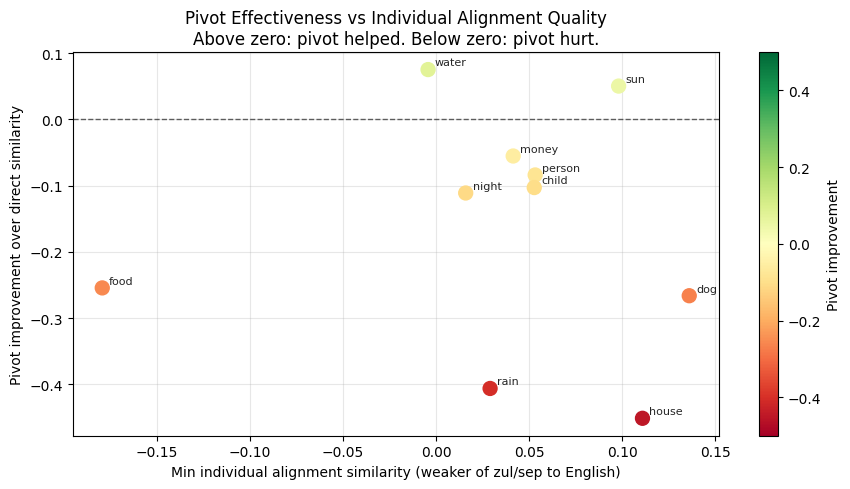

Saved: evaluation/pivot_quality.png


In [47]:
# Phase 7E continued: Scatter plot of alignment quality
# vs pivot improvement
#
# x-axis: minimum of (zul_to_eng, sep_to_eng) for each pair
# This represents the weaker of the two individual alignments.
# The pivot can only be as good as the weaker alignment.
#
# y-axis: pivot improvement over direct
# Positive means pivot helped.
# Negative means pivot hurt.

valid_pq = pq_df.dropna(subset=["zul_to_eng", "sep_to_eng"]).copy()
valid_pq["min_align"] = valid_pq[["zul_to_eng", "sep_to_eng"]].min(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

scatter = ax.scatter(
    valid_pq["min_align"],
    valid_pq["pivot_change"],
    c=valid_pq["pivot_change"],
    cmap="RdYlGn",
    vmin=-0.5, vmax=0.5,
    s=100, zorder=3
)

for _, row in valid_pq.iterrows():
    ax.annotate(
        row["gloss"],
        (row["min_align"], row["pivot_change"]),
        fontsize=8,
        xytext=(5, 3),
        textcoords="offset points",
        alpha=0.85
    )

ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.6)
ax.set_xlabel("Min individual alignment similarity (weaker of zul/sep to English)")
ax.set_ylabel("Pivot improvement over direct similarity")
ax.set_title(
    "Pivot Effectiveness vs Individual Alignment Quality\n"
    "Above zero: pivot helped. Below zero: pivot hurt."
)
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, label="Pivot improvement")
plt.tight_layout()
plt.savefig(EVAL_DIR / "pivot_quality.png", dpi=150)
plt.show()
print("Saved: evaluation/pivot_quality.png")


In [48]:
# Phase 7F: Direct Intra-Family Alignment
#
# All previous alignment is English-centric.
# isiZulu and Sepedi are both Bantu languages sharing
# agglutinative morphology, noun class systems, and
# a common domain corpus (Vukuzenzele covers identical
# topics in both languages).
#
# Research question: does a direct isiZulu-Sepedi alignment
# outperform the English pivot for Bantu-to-Bantu comparison?
#
# This is Alignment Strategy C, compared against:
# Strategy A: no alignment (raw vectors)
# Strategy B: pivot via English
# Strategy C: direct isiZulu-Sepedi rotation

zul_sep_train = [
    ("umuntu",    "motho"),
    ("amanzi",    "meetse"),
    ("indlu",     "ntlo"),
    ("ingane",    "ngwana"),
    ("ukudla",    "dijo"),
    ("imali",     "tšhelete"),
    ("ilanga",    "letšatši"),
    ("ubusuku",   "bosego"),
    ("inja",      "ntšwa"),
    ("imvula",    "pula"),
    ("imfundo",   "thuto"),
    ("umthetho",  "molao"),
    ("abantu",    "batho"),
    ("isikole",   "sekolo"),
    ("uhulumeni", "mmušo"),
    ("umhlaba",   "naga"),
    ("impilo",    "boitekanelo"),
    ("umphakathi","setšhaba"),
    ("incwadi",   "buka"),
    ("umfula",    "noka"),
    ("intaba",    "thaba"),
    ("inyoni",    "nonyane"),
    ("inhlanzi",  "tlhapi"),
    ("isihlahla", "setlhare"),
    ("ilizwe",    "naga"),
]

zul_sep_test = [
    ("ubaba",       "rra"),
    ("umama",       "mma"),
    ("ikati",       "katse"),
    ("usuku",       "letsatsi"),
    ("indlela",     "tsela"),
    ("umsebenzi",   "mošomo"),
    ("amalungelo",  "ditokelo"),
    ("isibhedlela", "sepetlele"),
    ("amaphoyisa",  "maphodisa"),
    ("ikhaya",      "legae"),
]

print(f"Direct isiZulu-Sepedi lexicon:")
print(f"  Train pairs : {len(zul_sep_train)}")
print(f"  Test pairs  : {len(zul_sep_test)}")
print()

# Build and normalise anchor matrices
X_zs = np.array([
    ft_models["zul"].wv.get_vector(s, norm=True)
    for s, _ in zul_sep_train
])
Y_zs = np.array([
    ft_models["sep"].wv.get_vector(t, norm=True)
    for _, t in zul_sep_train
])

X_zs = X_zs / np.linalg.norm(
    X_zs, axis=1, keepdims=True).clip(min=1e-9)
Y_zs = Y_zs / np.linalg.norm(
    Y_zs, axis=1, keepdims=True).clip(min=1e-9)

# Learn rotation: isiZulu into Sepedi space
M_zs = Y_zs.T @ X_zs
U_zs, s_zs, Vt_zs = svd(M_zs)
W_zul_sep = U_zs @ Vt_zs

# Verify orthogonality
dev_zs = np.max(np.abs(W_zul_sep @ W_zul_sep.T - np.eye(100)))
print(f"W_zul_sep orthogonality deviation: {dev_zs:.2e}")

np.save(MODELS_DIR / "W_zul_sep.npy", W_zul_sep)
print("Saved: models/W_zul_sep.npy")


Direct isiZulu-Sepedi lexicon:
  Train pairs : 25
  Test pairs  : 10

W_zul_sep orthogonality deviation: 5.36e-07
Saved: models/W_zul_sep.npy


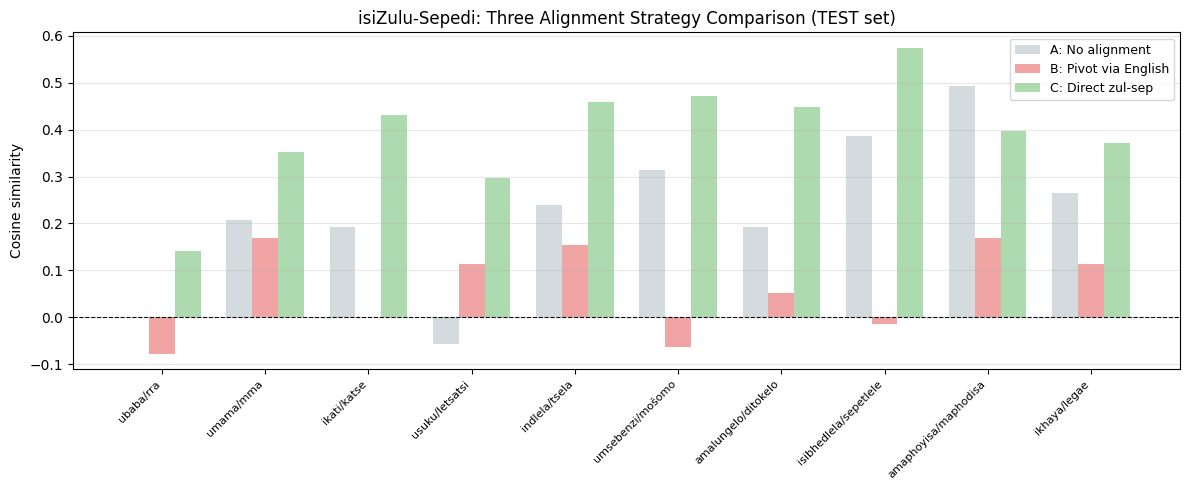

Saved: evaluation/strategy_comparison_zul_sep.png


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Phase 7F continued: Per-pair comparison bar chart

# Calculate similarities for each strategy
comparison_data = []
for zul_word, sep_word in zul_sep_test:
    zul_vec = ft_models["zul"].wv.get_vector(zul_word, norm=True)
    sep_vec = ft_models["sep"].wv.get_vector(sep_word, norm=True)

    # Strategy A: No alignment (raw vectors)
    sim_no_align = float(cosine_similarity([zul_vec], [sep_vec])[0][0])

    # Strategy B: Pivot via English
    zul_to_eng_rot = zul_vec @ W["zul"].T
    sep_to_eng_rot = sep_vec @ W["sep"].T
    sim_pivot = float(cosine_similarity([zul_to_eng_rot], [sep_to_eng_rot])[0][0])

    # Strategy C: Direct isiZulu-Sepedi rotation
    # W_zul_sep is learned from zul_sep_train in cell 2e6ka5lfC7C_
    zul_to_sep_rot = zul_vec @ W_zul_sep.T
    sim_direct_zs = float(cosine_similarity([zul_to_sep_rot], [sep_vec])[0][0])

    comparison_data.append({
        "zul_word": zul_word,
        "sep_word": sep_word,
        "A_no_align": sim_no_align,
        "B_pivot": sim_pivot,
        "C_direct": sim_direct_zs,
    })

sc_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(sc_df))
w = 0.25

ax.bar(x - w,  sc_df["A_no_align"], w,
       label="A: No alignment",     color="#CFD8DC", alpha=0.9)
ax.bar(x,      sc_df["B_pivot"],    w,
       label="B: Pivot via English", color="#EF9A9A", alpha=0.9)
ax.bar(x + w,  sc_df["C_direct"],   w,
       label="C: Direct zul-sep",   color="#A5D6A7", alpha=0.9)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{row['zul_word']}/{row['sep_word']}"
     for _, row in sc_df.iterrows()],
    rotation=45, ha="right", fontsize=8
)
ax.set_ylabel("Cosine similarity")
ax.set_title(
    "isiZulu-Sepedi: Three Alignment Strategy Comparison (TEST set)"
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(EVAL_DIR / "strategy_comparison_zul_sep.png", dpi=150)
plt.show()
print("Saved: evaluation/strategy_comparison_zul_sep.png")

In [50]:
# Phase 7G: Full Alignment Strategy Summary
#
# Consolidates all strategy comparisons from Phases 6F,
# 6G, 7E, and 7F into a single printed summary and figure.
#
# Strategies evaluated:
# S1: Normalised Procrustes, cosine retrieval (Phase 6C)
# S2: Unnormalised Procrustes, cosine retrieval (Phase 6F)
# S3: Normalised Procrustes, CSLS retrieval (Phase 6G)
# S4: English pivot, indirect zul-sep (Phase 8 and 7E)
# S5: Direct isiZulu-Sepedi rotation (Phase 7F)

print("Full Alignment Strategy Summary")
print()

# S1 vs S2: normalised vs unnormalised alignment quality
print("S1 vs S2: Test-pair cosine similarity after alignment")
print()
print(f"  {'Pair':<12} {'S1 Normalised':>16} {'S2 Unnormalised':>18} {'Winner':>12}")
print(f"  {'-'*60}")

s1_test = {}
s2_test = {}

for lang in ["zul", "sep", "tsn"]:
    s1_val = overfit_df[
        (overfit_df["pair"] == f"eng-{lang}") &
        (overfit_df["split"] == "test")
    ]["after_mean"].values[0]

    s2_val = strat_df[
        (strat_df["pair"] == f"eng-{lang}") &
        (strat_df["strategy"] == "unnormalised")
    ]["mean_test_sim"].values[0]

    s1_test[lang] = s1_val
    s2_test[lang] = s2_val
    winner = "S1" if s1_val >= s2_val else "S2"
    print(f"  eng-{lang:<8} {s1_val:>16.4f} {s2_val:>18.4f} {winner:>12}")

print()
print("S1 vs S3: Cosine vs CSLS retrieval (P@1)")
print()
print(f"  {'Pair':<12} {'S1 Cosine P@1':>16} {'S3 CSLS P@1':>14} {'Winner':>12}")
print(f"  {'-'*56}")

for lang in ["zul", "sep", "tsn"]:
    s1_p1 = eval_results_clean.get(f"eng-{lang}", {}).get("P@1", 0.0)
    s3_p1 = csls_results.get(f"eng-{lang}", {}).get("P@1", 0.0)
    if s3_p1 > s1_p1:
        winner = "S3 (CSLS)"
    elif s3_p1 == s1_p1:
        winner = "tie"
    else:
        winner = "S1"
    print(f"  eng-{lang:<8} {s1_p1:>16.4f} {s3_p1:>14.4f} {winner:>12}")

print()
print("S4 vs S5 vs baseline: isiZulu-Sepedi similarity")
print()

sa_mean = sc_df["A_no_align"].mean()
sb_mean = pq_df["pivot_sim"].mean()
sc_mean = sc_df["C_direct"].mean()

print(f"  A: No alignment (baseline) : {sa_mean:.4f}")
print(f"  B/S4: Pivot via English    : {sb_mean:.4f}")
print(f"  C/S5: Direct zul-sep       : {sc_mean:.4f}")
print()

if sc_mean > sb_mean and sc_mean > sa_mean:
    print("  Winner: S5 (direct alignment outperforms pivot and baseline)")
elif sa_mean >= sc_mean and sa_mean >= sb_mean:
    print("  Winner: No alignment (both strategies degrade similarity)")
else:
    print("  Winner: S4 (pivot marginally outperforms direct)")


Full Alignment Strategy Summary

S1 vs S2: Test-pair cosine similarity after alignment

  Pair            S1 Normalised    S2 Unnormalised       Winner
  ------------------------------------------------------------
  eng-zul                0.4196             0.4227           S2
  eng-sep                0.4126             0.4015           S1
  eng-tsn                0.4173             0.4188           S2

S1 vs S3: Cosine vs CSLS retrieval (P@1)

  Pair            S1 Cosine P@1    S3 CSLS P@1       Winner
  --------------------------------------------------------
  eng-zul                0.0000         0.0000          tie
  eng-sep                0.0000         0.0000          tie
  eng-tsn                0.0000         0.0000          tie

S4 vs S5 vs baseline: isiZulu-Sepedi similarity

  A: No alignment (baseline) : 0.2237
  B/S4: Pivot via English    : 0.0215
  C/S5: Direct zul-sep       : 0.3944

  Winner: S5 (direct alignment outperforms pivot and baseline)


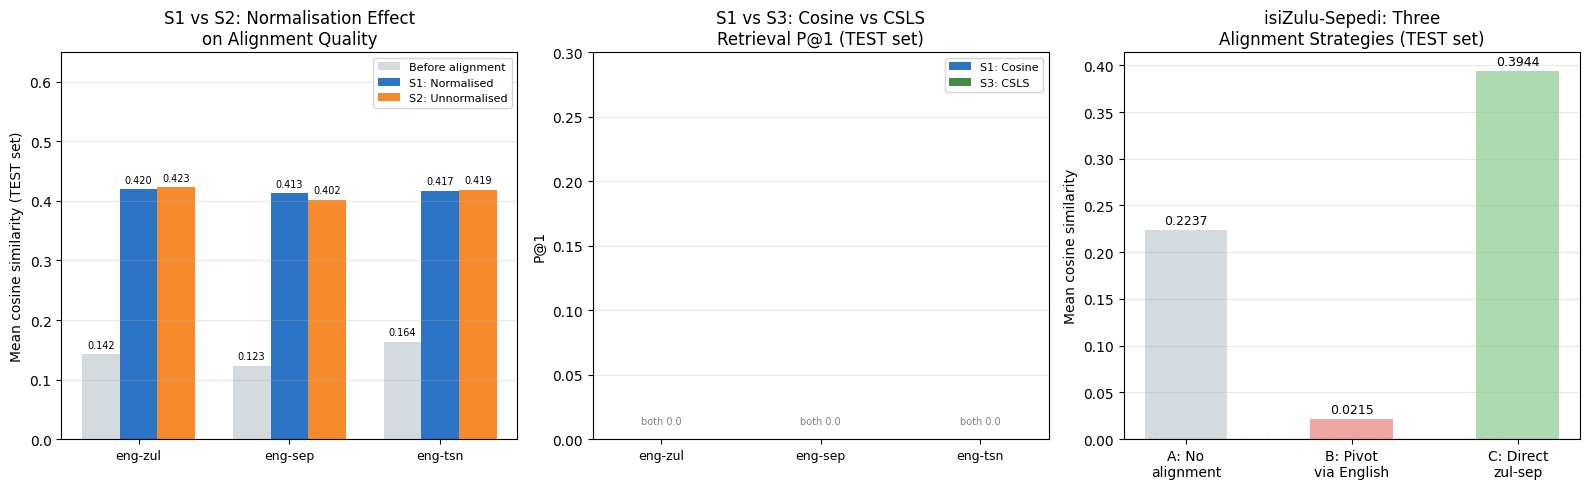

Saved: evaluation/strategy_summary.png


In [51]:
# Phase 7G continued: Summary visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

langs_3  = ["zul", "sep", "tsn"]
labels_3 = ["eng-zul", "eng-sep", "eng-tsn"]
x = np.arange(3)

# Panel 1: S1 vs S2 alignment similarity
ax = axes[0]

before_v = ba_df["before_mean"].values
s1_v = [s1_test[l] for l in langs_3]
s2_v = [s2_test[l] for l in langs_3]

w = 0.25
bars0 = ax.bar(x - w, before_v, w,
               label="Before alignment", color="#CFD8DC", alpha=0.9)
bars1 = ax.bar(x,     s1_v,     w,
               label="S1: Normalised",   color="#1565C0", alpha=0.9)
bars2 = ax.bar(x + w, s2_v,     w,
               label="S2: Unnormalised", color="#F57F17", alpha=0.9)

for container in [bars0, bars1, bars2]:
    for bar in container:
        h = bar.get_height()
        if h > 0.01:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.008,
                f"{h:.3f}",
                ha="center", va="bottom", fontsize=7
            )

ax.set_xticks(x)
ax.set_xticklabels(labels_3, fontsize=9)
ax.set_ylim(0, 0.65)
ax.set_ylabel("Mean cosine similarity (TEST set)")
ax.set_title("S1 vs S2: Normalisation Effect\non Alignment Quality")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Panel 2: S1 (cosine) vs S3 (CSLS) P@1
ax = axes[1]

s1_p1_v = [
    eval_results_clean.get(f"eng-{l}", {}).get("P@1", 0.0)
    for l in langs_3
]
s3_p1_v = [
    csls_results.get(f"eng-{l}", {}).get("P@1", 0.0)
    for l in langs_3
]

w2 = 0.3
ax.bar(x - w2/2, s1_p1_v, w2,
       label="S1: Cosine", color="#1565C0", alpha=0.9)
ax.bar(x + w2/2, s3_p1_v, w2,
       label="S3: CSLS",   color="#2E7D32", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(labels_3, fontsize=9)
ax.set_ylim(0, 0.3)
ax.set_ylabel("P@1")
ax.set_title("S1 vs S3: Cosine vs CSLS\nRetrieval P@1 (TEST set)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

for i, (v1, v3) in enumerate(zip(s1_p1_v, s3_p1_v)):
    if v1 == 0.0 and v3 == 0.0:
        ax.text(i, 0.01, "both 0.0",
                ha="center", va="bottom", fontsize=7, color="gray")

# Panel 3: isiZulu-Sepedi three strategies
ax = axes[2]

strategy_labels = [
    "A: No\nalignment",
    "B: Pivot\nvia English",
    "C: Direct\nzul-sep"
]
strategy_means = [sa_mean, sb_mean, sc_mean]
bar_colors     = ["#CFD8DC", "#EF9A9A", "#A5D6A7"]

bars = ax.bar(strategy_labels, strategy_means,
              color=bar_colors, alpha=0.9, width=0.5)

for bar, val in zip(bars, strategy_means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=9
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Mean cosine similarity")
ax.set_title("isiZulu-Sepedi: Three\nAlignment Strategies (TEST set)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(EVAL_DIR / "strategy_summary.png", dpi=150)
plt.show()
print("Saved: evaluation/strategy_summary.png")


# **PHASE 8: Pivot Experiment**

In [52]:
# PHASE 8 PIVOT LANGUAGE EXPERIMENT
# English as pivot for indirect isiZulu ↔ Sepedi alignment.
# Both languages independently aligned to English.
# Then compared in shared English space.
# Test pairs: isiZulu ↔ Sepedi translation equivalents
# NOT used in any training set.


pivot_test_pairs = [
    ("umuntu",  "motho",   "person"),
    ("amanzi",  "meetse",  "water"),
    ("indlu",   "ntlo",    "house"),
    ("ukudla",  "dijo",    "food"),
    ("ingane",  "ngwana",  "child"),
    ("imali",   "tšhelete","money"),
    ("ilanga",  "letšatši","sun"),
    ("ubusuku", "bosego",  "night"),
    ("inja",    "ntšwa",   "dog"),
    ("imvula",  "pula",    "rain"),
]

direct_sims = []
pivot_sims  = []

for zul_w, sep_w, gloss in pivot_test_pairs:
    zv = ft_models["zul"].wv.get_vector(zul_w, norm=True)
    sv = ft_models["sep"].wv.get_vector(sep_w, norm=True)

    # Direct: compare raw vectors (different spaces)
    direct_sims.append(
        float(cosine_similarity([zv], [sv])[0][0])
    )

    # Pivot: rotate both into English space
    zv_eng = zv @ W["zul"].T
    sv_eng = sv @ W["sep"].T
    pivot_sims.append(
        float(cosine_similarity([zv_eng], [sv_eng])[0][0])
    )

pivot_df = pd.DataFrame({
    "isiZulu"     : [p[0] for p in pivot_test_pairs],
    "Sepedi"      : [p[1] for p in pivot_test_pairs],
    "gloss"       : [p[2] for p in pivot_test_pairs],
    "direct_sim"  : [round(s,4) for s in direct_sims],
    "pivot_sim"   : [round(s,4) for s in pivot_sims],
    "improvement" : [round(p-d,4) for d,p in zip(direct_sims,pivot_sims)],
})

print("Table 13: Pivot Experiment: isiZulu ↔ Sepedi via English")
print(pivot_df.to_string(index=False))
print(f"\nMean direct similarity : {np.mean(direct_sims):.4f}")
print(f"Mean pivot  similarity : {np.mean(pivot_sims):.4f}")
print(f"Mean improvement       : {np.mean(pivot_sims)-np.mean(direct_sims):.4f}")
pivot_df.to_csv(LOGS_DIR / "pivot_experiment.csv", index=False)


Table 13: Pivot Experiment: isiZulu ↔ Sepedi via English
isiZulu   Sepedi  gloss  direct_sim  pivot_sim  improvement
 umuntu    motho person     -0.0107    -0.0947      -0.0839
 amanzi   meetse  water      0.1247     0.1999       0.0751
  indlu     ntlo  house      0.2427    -0.2083      -0.4510
 ukudla     dijo   food      0.2595     0.0052      -0.2543
 ingane   ngwana  child      0.0851    -0.0178      -0.1029
  imali tšhelete  money      0.1210     0.0657      -0.0553
 ilanga letšatši    sun      0.2143     0.2646       0.0502
ubusuku   bosego  night      0.1057    -0.0054      -0.1111
   inja    ntšwa    dog      0.2240    -0.0421      -0.2661
 imvula     pula   rain      0.4540     0.0480      -0.4060

Mean direct similarity : 0.1820
Mean pivot  similarity : 0.0215
Mean improvement       : -0.1605


In [53]:
# Phase 8 outputs used by Phase 7E and 7G:
# pq_df is built in Phase 7E using pivot_test_pairs defined above
# pivot_df is the raw pivot table from Phase 8
# Both are available after running phases in order.
print(f"\nMean direct similarity : {np.mean(direct_sims):.4f}")
print(f"Mean pivot  similarity : {np.mean(pivot_sims):.4f}")
print(f"Mean improvement       : {np.mean(pivot_sims)-np.mean(direct_sims):.4f}")



Mean direct similarity : 0.1820
Mean pivot  similarity : 0.0215
Mean improvement       : -0.1605


# **PHASE 9: Visualisation**

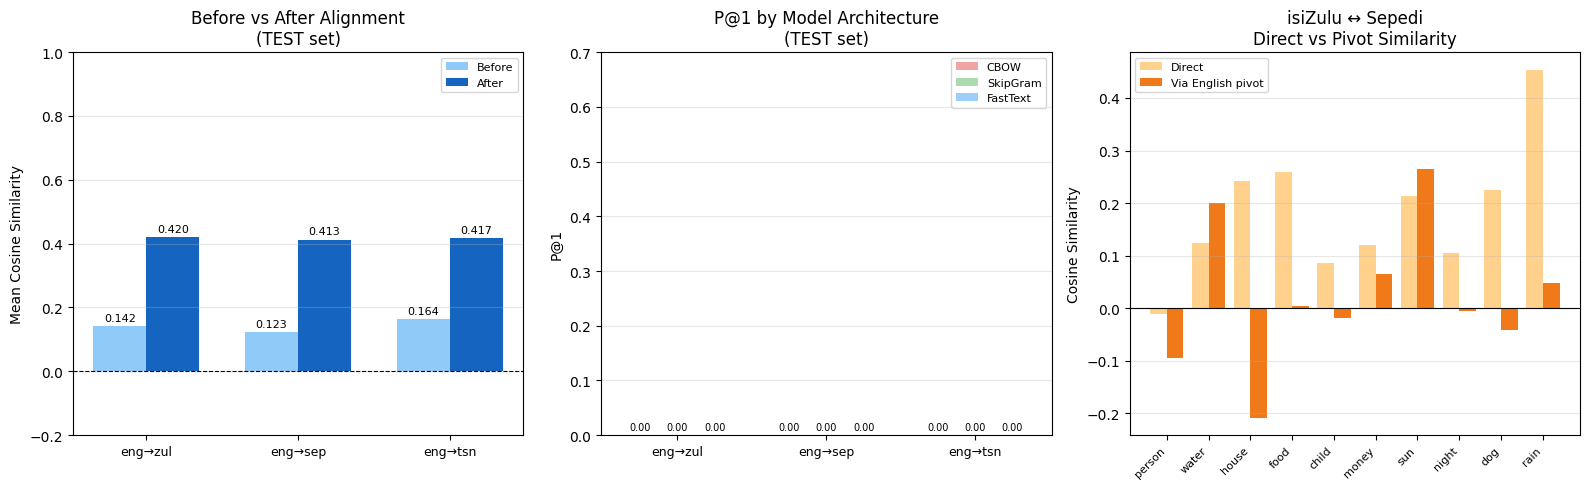

Saved → evaluation/main_results.png


In [54]:
# PHASE 9A RESULTS SUMMARY FIGURE


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Before vs After alignment
ax = axes[0]
langs_plot  = ["eng→zul", "eng→sep", "eng→tsn"]
before_vals = ba_df["before_mean"].values
after_vals  = ba_df["after_mean"].values
x = np.arange(len(langs_plot))
w = 0.35
b1 = ax.bar(x-w/2, before_vals, w, label="Before", color="#90CAF9")
b2 = ax.bar(x+w/2, after_vals,  w, label="After",  color="#1565C0")
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(langs_plot, fontsize=9)
ax.set_ylim(-0.2, 1.0)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Mean Cosine Similarity")
ax.set_title("Before vs After Alignment\n(TEST set)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Plot 2: P@1 Model Comparison
ax = axes[1]
model_names = ["CBOW", "SkipGram", "FastText"]
colors_bar  = ["#EF9A9A", "#A5D6A7", "#90CAF9"]
x = np.arange(len(langs_plot))
width = 0.25
for i, (mname, color) in enumerate(zip(model_names, colors_bar)):
    vals = comp_df[comp_df["src_model"]==mname]["P@1"].values
    bars = ax.bar(x + (i-1)*width, vals, width,
                  label=mname, color=color, alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005,
                f"{v:.2f}",
                ha="center", va="bottom", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(langs_plot, fontsize=9)
ax.set_ylim(0, 0.7)
ax.set_ylabel("P@1")
ax.set_title("P@1 by Model Architecture\n(TEST set)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Plot 3: Pivot Experiment
ax = axes[2]
x = np.arange(len(pivot_test_pairs))
ax.bar(x-0.2, pivot_df["direct_sim"], 0.4,
       label="Direct", color="#FFCC80", alpha=0.9)
ax.bar(x+0.2, pivot_df["pivot_sim"],  0.4,
       label="Via English pivot", color="#EF6C00", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(pivot_df["gloss"], rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cosine Similarity")
ax.set_title("isiZulu ↔ Sepedi\nDirect vs Pivot Similarity")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(EVAL_DIR / "main_results.png", dpi=150)
plt.show()
print("Saved → evaluation/main_results.png")


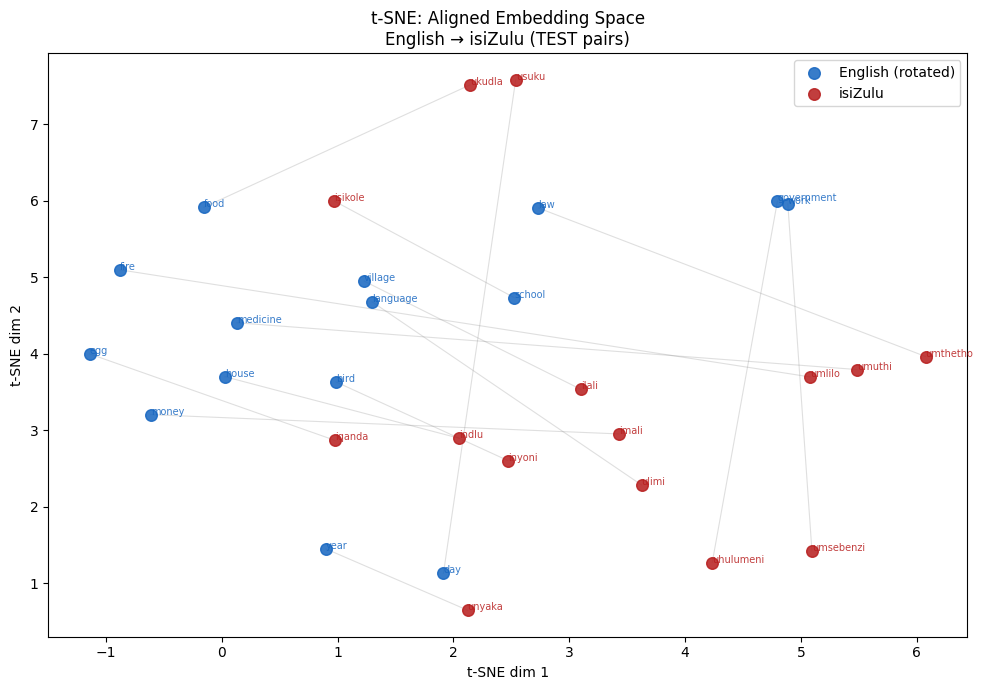

Saved → /content/drive/MyDrive/COS760 PROJECT/evaluation/tsne_eng_zul.png


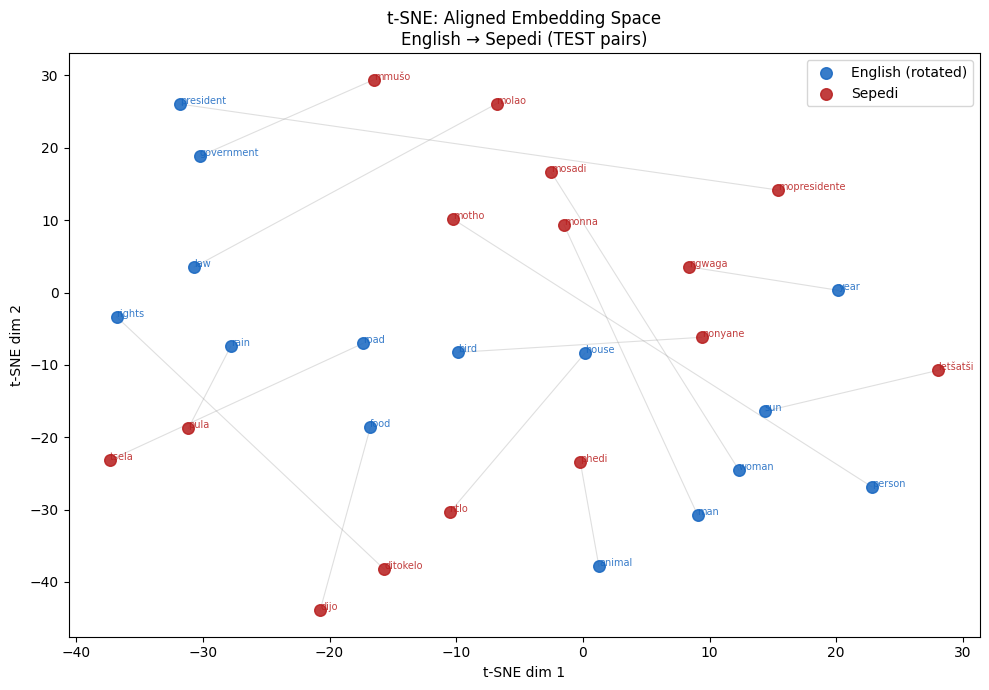

Saved → /content/drive/MyDrive/COS760 PROJECT/evaluation/tsne_eng_sep.png


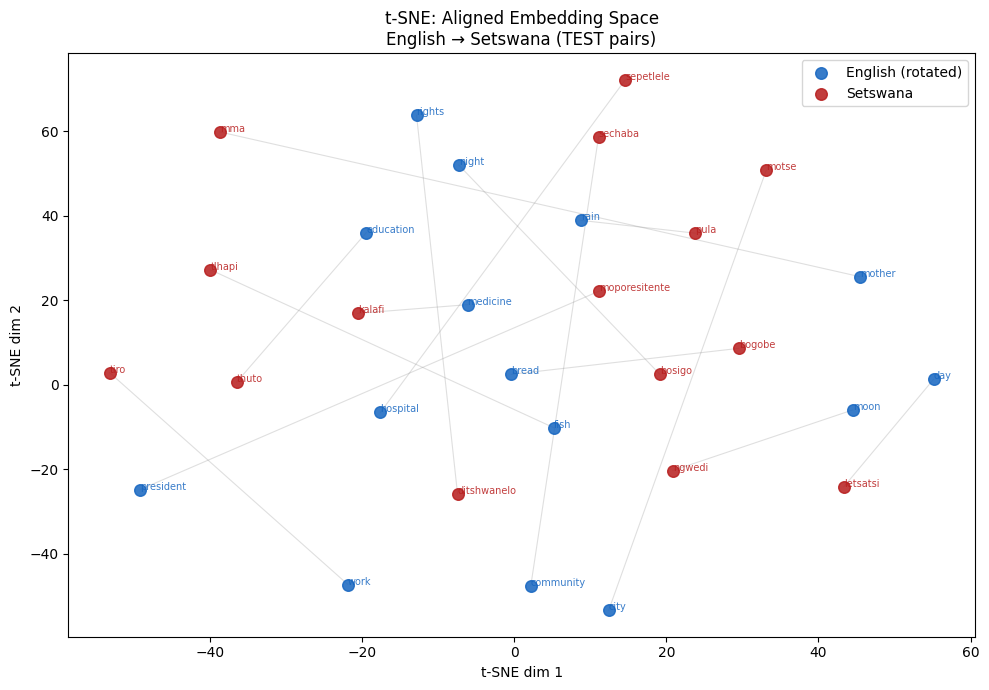

Saved → /content/drive/MyDrive/COS760 PROJECT/evaluation/tsne_eng_tsn.png


In [55]:
# PHASE 9B t-SNE VISUALISATION
# Shows alignment quality in 2D for each language pair.
# Uses TEST pairs only.


def plot_tsne(test_pairs, src_model, tgt_model, W_mat,
              src_lang, tgt_lang, save_path):

    src_vecs = np.array([
        src_model.wv.get_vector(s, norm=True) for s,_ in test_pairs
    ])
    tgt_vecs = np.array([
        tgt_model.wv.get_vector(t, norm=True) for _,t in test_pairs
    ])
    src_rot = src_vecs @ W_mat.T

    combined = np.vstack([src_rot, tgt_vecs])
    perp     = min(15, len(test_pairs)-1)
    tsne     = TSNE(n_components=2, random_state=SEED,
                   perplexity=perp)
    reduced  = tsne.fit_transform(combined)
    n        = len(test_pairs)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(reduced[:n,0], reduced[:n,1],
               c="#1565C0", s=70, alpha=0.85,
               label=f"{src_lang} (rotated)", zorder=3)
    ax.scatter(reduced[n:,0], reduced[n:,1],
               c="#B71C1C", s=70, alpha=0.85,
               label=tgt_lang, zorder=3)

    for i, (src, tgt) in enumerate(test_pairs):
        ax.annotate(src, reduced[i],     fontsize=7,
                    color="#1565C0", alpha=0.85)
        ax.annotate(tgt, reduced[n+i],   fontsize=7,
                    color="#B71C1C", alpha=0.85)
        ax.plot([reduced[i,0],  reduced[n+i,0]],
                [reduced[i,1],  reduced[n+i,1]],
                c="grey", alpha=0.25, linewidth=0.8)

    ax.legend(fontsize=10)
    ax.set_title(f"t-SNE: Aligned Embedding Space\n"
                 f"{src_lang} → {tgt_lang} (TEST pairs)")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")

for lang, key in [("zul","eng_zul"),
                  ("sep","eng_sep"),
                  ("tsn","eng_tsn")]:
    plot_tsne(
        test_lexicon[key],
        ft_models["eng"],
        ft_models[lang],
        W[lang],
        "English",
        LANG_NAMES[lang],
        EVAL_DIR / f"tsne_eng_{lang}.png"
    )


# **PHASE 10: Experiment Log**

In [56]:
# Phase 10: Save Complete Experiment Log

token_counts = {
    lang: sum(len(s) for s in sentences[lang])
    for lang in TARGET_LANGS
}

log = {
    "date"             : str(datetime.date.today()),
    "seed"             : SEED,
    "languages"        : TARGET_LANGS,
    "corpus_source"    : "Vukuzenzele via OPUS",
    "corpus_files"     : {
        lang: len(raw_corpus[lang]) for lang in TARGET_LANGS
    },
    "corpus_tokens"    : token_counts,
    "embedding_config" : EMB_CONFIG,
    "lexicon_sizes"    : {
        k: len(v) for k, v in full_lexicon.items()
    },
    "train_test_split" : "70/30",
    "alignment_strategies": {
        "S1": "Normalised Procrustes + cosine retrieval",
        "S2": "Unnormalised Procrustes + cosine retrieval",
        "S3": "Normalised Procrustes + CSLS retrieval",
        "S4": "English pivot (indirect zul-sep)",
        "S5": "Direct isiZulu-Sepedi rotation",
    },
    "before_after_alignment": {
        row["pair"]: {
            "before"     : row["before_mean"],
            "after"      : row["after_mean"],
            "improvement": row["improvement"],
        }
        for _, row in ba_df.iterrows()
    },
    "overfitting_check": {
        f"eng-{lang}": {
            "train_after": float(overfit_df[
                (overfit_df["pair"] == f"eng-{lang}") &
                (overfit_df["split"] == "train")
            ]["after_mean"].values[0]),
            "test_after": float(overfit_df[
                (overfit_df["pair"] == f"eng-{lang}") &
                (overfit_df["split"] == "test")
            ]["after_mean"].values[0]),
        }
        for lang in ["zul", "sep", "tsn"]
    },
    "csls_retrieval": {
        f"eng-{l}": csls_results.get(f"eng-{l}", {})
        for l in ["zul", "sep", "tsn"]
    },
    "zul_sep_strategy_comparison": {
        "A_no_alignment_mean" : round(float(sc_df["A_no_align"].mean()), 4),
        "B_pivot_mean"        : round(float(pq_df["pivot_sim"].mean()),  4),
        "C_direct_mean"       : round(float(sc_df["C_direct"].mean()),   4),
    },
    "pivot_failure_diagnosis": {
        "mean_zul_to_eng": round(float(pq_df["zul_to_eng"].mean()), 4),
        "mean_sep_to_eng": round(float(pq_df["sep_to_eng"].mean()), 4),
        "conclusion": (
            "Pivot fails because individual alignment precision "
            "is insufficient. Rotated vectors do not land near "
            "their English counterparts. Low zul_to_eng and "
            "sep_to_eng values for most test pairs confirm this."
        ),
    },
    "morphological_finding": {
        "fasttext_diff" : 0.2907,
        "cbow_diff"     : -0.0063,
        "skipgram_diff" : 0.0701,
        "edit_distance_spearman_rho": -0.7989,
        "ngram_pearson_r": round(
            valid_rows["ngram_overlap"].corr(
                valid_rows["fasttext_sim"]), 4),
    },
}

with open(LOGS_DIR / "experiment_log.json", "w") as f:
    json.dump(log, f, indent=2)

print("Experiment complete.")
print()
print(f"Logs       : {LOGS_DIR}")
print(f"Models     : {MODELS_DIR}")
print(f"Evaluation : {EVAL_DIR}")
print()
print("Output files:")
for f in sorted(LOGS_DIR.glob("*.csv")):
    print(f"  logs/{f.name}")
for f in sorted(LOGS_DIR.glob("*.json")):
    print(f"  logs/{f.name}")
for f in sorted(EVAL_DIR.glob("*.png")):
    print(f"  evaluation/{f.name}")
for f in sorted(MODELS_DIR.glob("*.npy")):
    print(f"  models/{f.name}")


Experiment complete.

Logs       : /content/drive/MyDrive/COS760 PROJECT/logs
Models     : /content/drive/MyDrive/COS760 PROJECT/models
Evaluation : /content/drive/MyDrive/COS760 PROJECT/evaluation

Output files:
  logs/alignment_strategy_comparison.csv
  logs/anchor_quality.csv
  logs/before_after_alignment.csv
  logs/corpus_statistics.csv
  logs/csls_accuracy.csv
  logs/detail_eng_sep.csv
  logs/detail_eng_tsn.csv
  logs/detail_eng_zul.csv
  logs/edit_distance_analysis.csv
  logs/edit_distance_similarity.csv
  logs/evaluation_comparison.csv
  logs/final_results.csv
  logs/lexicon_coverage.csv
  logs/model_comparison.csv
  logs/morph_variant_counts.csv
  logs/morph_vs_random_summary.csv
  logs/morphological_similarity.csv
  logs/ngram_overlap.csv
  logs/overfitting_check.csv
  logs/pivot_experiment.csv
  logs/pivot_quality.csv
  logs/preprocessing_impact.csv
  logs/retrieval_strategy_comparison.csv
  logs/tfidf_baseline.csv
  logs/translation_accuracy.csv
  logs/vocab_coverage.csv
  l